In [ ]:
from  google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Importation des bibliothèques**



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score,confusion_matrix, classification_report,mean_squared_error,r2_score,roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE =42
np.random.seed(RANDOM_STATE)
import matplotlib.gridspec as gridspec
from itertools import combinations


2. **Chargement du dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PJT_2026/drone_simulation_Good.csv')
df.head()

,timestamp,courant_main,courant_tail,angle_gauche,angle_droite,angle_nacelle,ax_G,ay_G,az_G,ax_D,ay_D,az_D,distance,label_defaut,amplitude_defaut,localisation_defaut
0,2025-01-01 00:00:00.000,0.509934,0.486496,-0.086349,-0.111408,-0.001651,-0.101774,0.176222,9.776364,0.131896,0.048275,9.862243,29.321184,normal,0.0,aucune
1,2025-01-01 00:00:00.100,0.497235,0.497110,-0.003120,-0.063093,-0.025183,-0.045825,-0.281847,9.778375,0.005896,-0.117204,9.852499,29.936605,normal,0.0,aucune
2,2025-01-01 00:00:00.200,0.512954,0.484152,0.001802,-0.094206,-0.008619,-0.089607,-0.049169,10.145314,-0.136849,0.103703,9.669522,30.576884,normal,0.0,aucune
3,2025-01-01 00:00:00.300,0.530461,0.493841,0.047263,-0.054800,0.035737,0.016563,-0.006249,9.931397,-0.069375,-0.088554,9.896938,30.034326,normal,0.0,aucune
4,2025-01-01 00:00:00.400,0.495317,0.462128,-0.136686,-0.021415,0.063893,0.179577,0.002386,10.182098,0.051428,0.112433,9.586488,30.469544,normal,0.0,aucune


In [ ]:

df['amplitude_defaut'].value_counts()

,count
amplitude_defaut,
1.0,4000
0.0,2000
0.5,1500
0.6,1000
0.4,1000
0.7,1000
0.3,1000
0.8,500


In [ ]:
df.shape

(12000, 16)

In [ ]:
df['localisation_defaut'].value_counts()

,count
localisation_defaut,
aucune,2000
centrale_nacelle,2000
bras_horizontal,2000
base_alimentation,1000
moteur_gauche,1000
glissiere_verticale,1000
helice_gauche,1000
moteur_droit,500
helice_droite,500


In [ ]:
df['label_defaut'].value_counts()

,count
label_defaut,
normal,2000
coupure_moteur,500
blocage_moteur,500
usure_moteur,500
defaut_esc,500
helice_fendue,500
helice_desequilibree,500
helice_inversee,500
desequilibre_balancier,500


**Analyse Exploratoire des Données**

1.**Exploration générale**

In [ ]:
def explore_data(df: pd.DataFrame) -> None :
    print(f"\n Dimensions de notre dataset est : {df.shape}")
    print(f"\n Types de features sont :")
    print(df.dtypes.to_string())
    print("\n Voici une statistique descriptive de toutes les features : ")
    desc = df.describe(include="all").T
    desc["unique"] = df.nunique(dropna=True)
    desc["top"] = df.apply(lambda x: x.value_counts(dropna=True).idxmax() if not x.value_counts(dropna=True).empty else "Non applicable")
    desc["freq"] = df.apply(lambda x: x.value_counts(dropna=True).max() if not x.value_counts(dropna=True).empty else 0)
    desc = desc.fillna("Non applicable")
    print(desc.to_string())
    print('\n Les valeurs manquantes sont suivantes : ')
    missing = df.isnull().sum()
    missing_pct = missing / len(df) * 100
    missing_df = pd.DataFrame({"Nombre": missing,"Pourcentage": missing_pct.round(2)})
    missing_df = missing_df[missing_df["Nombre"] > 0]
    if missing_df.empty:
        print(" Aucune valeur manquante détectée. ")
    else :
        print(missing_df.to_string())
    print(f"\n Doublons sont de taille : {df.duplicated().sum()}")
    print(f"\n Cardinalite des features categorielles : ")
    cat_cols = df.select_dtypes(include=['object', "category"]).columns
    if len(cat_cols) == 0 :
        print("Aucune feature catégorielle.")
    else:
        for col in cat_cols:
            print(f"{col} : {df[col].nunique()} valeurs uniques -> {df[col].value_counts().head(3).to_dict()}")
explore_data(df)


 Dimensions de notre dataset est : (12000, 16)

 Types de features sont :
timestamp               object
courant_main           float64
courant_tail           float64
angle_gauche           float64
angle_droite           float64
angle_nacelle          float64
ax_G                   float64
ay_G                   float64
az_G                   float64
ax_D                   float64
ay_D                   float64
az_D                   float64
distance               float64
label_defaut            object
amplitude_defaut       float64
localisation_defaut     object

 Voici une statistique descriptive de toutes les features : 
                       count  unique                      top  freq            mean             std             min             25%             50%             75%             max
timestamp            12000.0    2000  2025-01-01 00:00:34.600    21  Non applicable  Non applicable  Non applicable  Non applicable  Non applicable  Non applicable  Non applicable
courant

**2. Analyse des distributions**

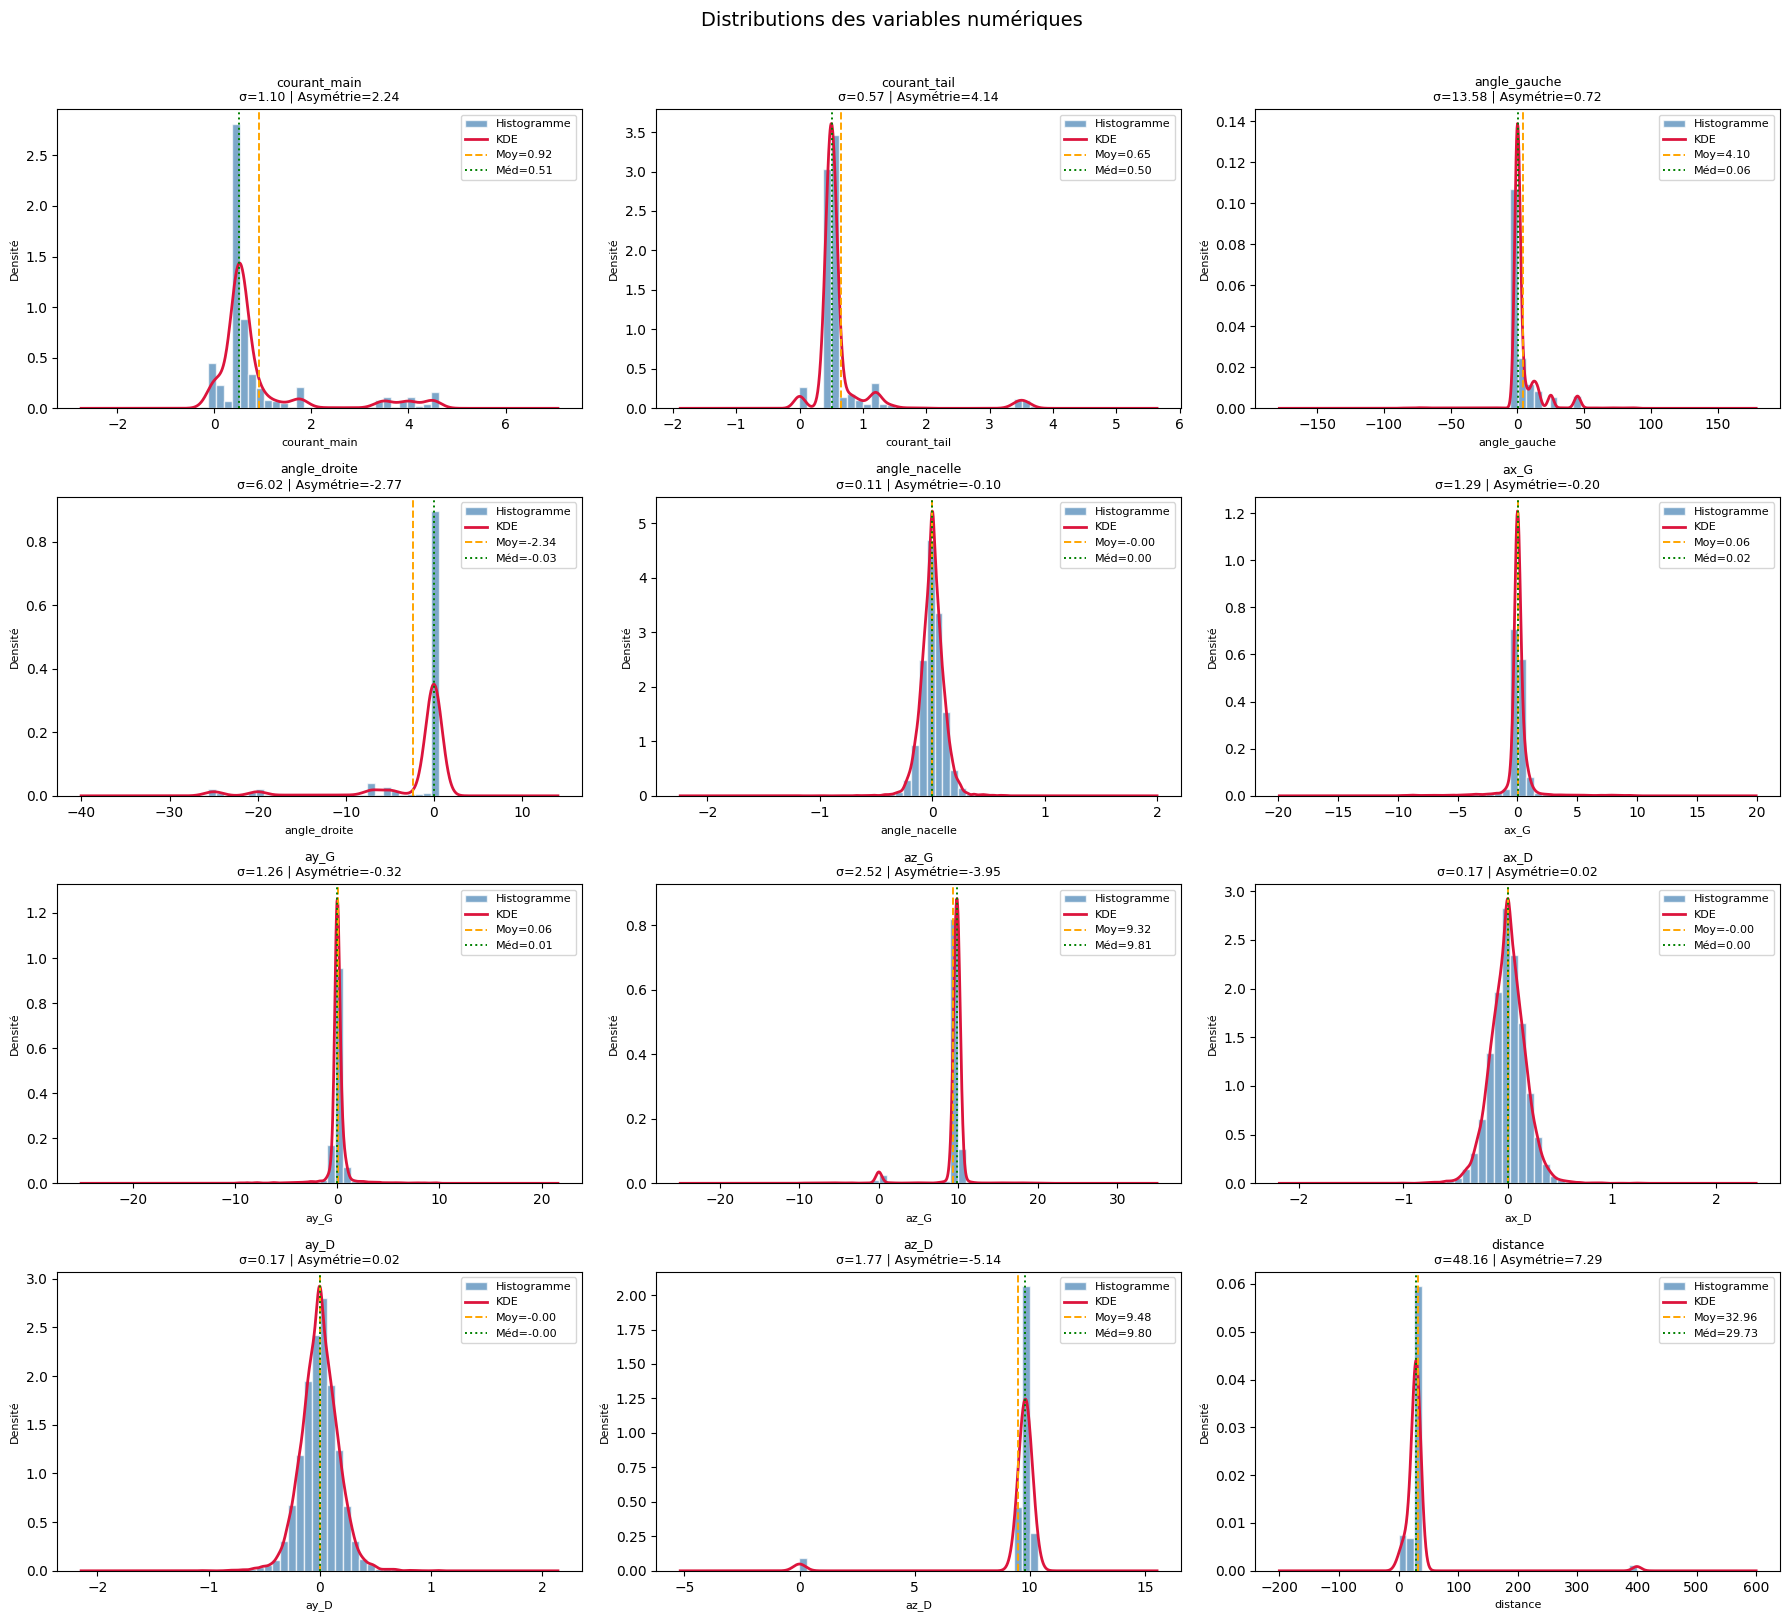

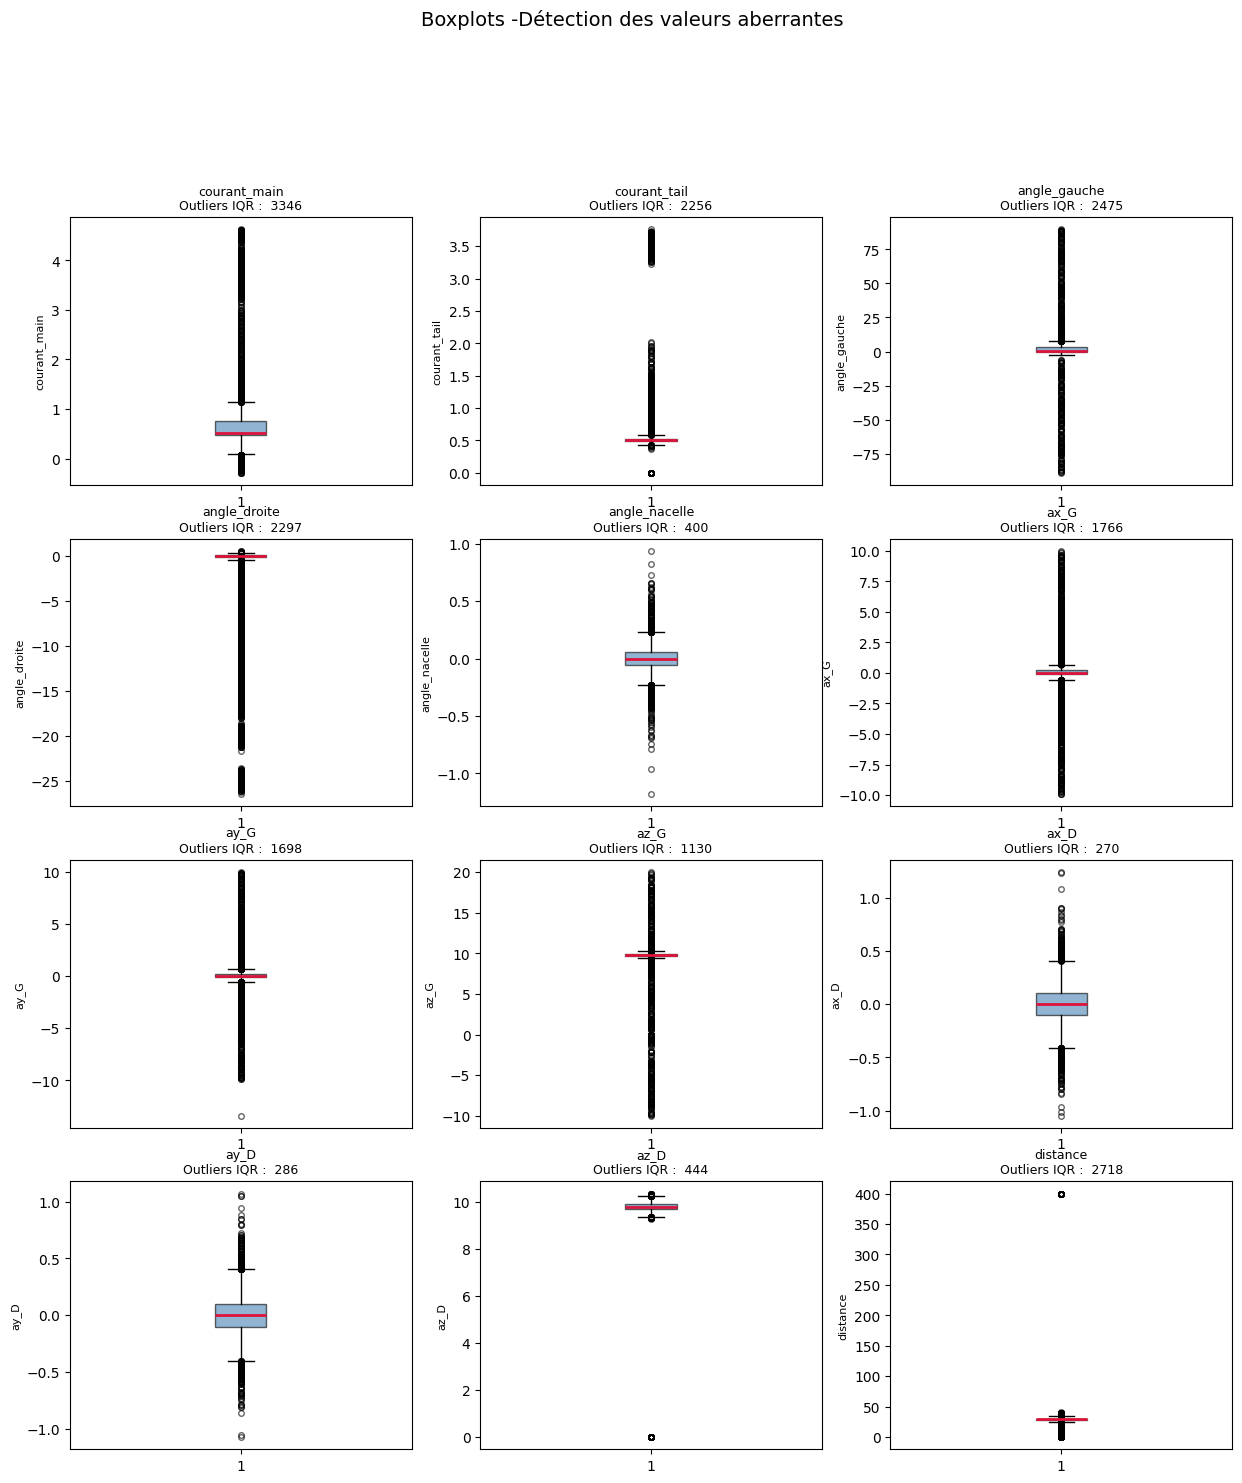

In [ ]:
data=df.copy()
target_cols= [data.columns[data.columns.get_loc('label_defaut')], data.columns[data.columns.get_loc('amplitude_defaut')],data.columns[data.columns.get_loc('localisation_defaut')]]
target_cols
def data_distribution(df:pd.DataFrame, target_cols:list= None) -> None :
  num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
  if target_cols:
        num_cols = [col for col in num_cols if col not in target_cols]
  if not num_cols :
    print("Aucune colonne numérique trouvée.")
    return
  ncols = 3
  nrows =(len(num_cols) + ncols - 1) // ncols
  fig, axes = plt.subplots(nrows,ncols, figsize=(6*ncols, 4*nrows))
  axes = np.array(axes).flatten()
  fig.suptitle("Distributions des variables numériques ", fontsize =14,y=1.01)
  for i, col in enumerate(num_cols):
    data =df[col].dropna()
    mean, med, std =data.mean(),data.median(), data.std()
    skew = data.skew()
    axes[i].hist(data,bins=30,density=True,color="steelblue",edgecolor="white", alpha=0.7, label="Histogramme")
    data.plot.kde(ax=axes[i],color="crimson",linewidth=2,label="KDE")
    axes[i].axvline(mean,color="orange",linestyle="--", linewidth=1.4, label=f"Moy={mean:.2f}")
    axes[i].axvline(med, color="green", linestyle=":",  linewidth=1.4, label=f"Méd={med:.2f}")
    axes[i].set_title(f"{col}\nσ={std:.2f} | Asymétrie={skew:.2f}", fontsize=9)
    axes[i].set_xlabel(col, fontsize =8)
    axes[i].set_ylabel("Densité",fontsize=8)
    axes[i].legend(fontsize = 8)
  for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
  plt.tight_layout()
  plt.show()
  fig2,axes2=plt.subplots(nrows, ncols, figsize=(5*ncols,4*nrows))
  axes2=np.array(axes2).flatten()
  fig2.suptitle("Boxplots -Détection des valeurs aberrantes", fontsize=14, y=1.01)
  for i, col in enumerate(num_cols):
    data=df[col].dropna()
    q1,q3=data.quantile(0.25),data.quantile(0.75)
    iqr= q3-q1
    n_outliers = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    axes2[i].boxplot(data,vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue",alpha=0.6),medianprops=dict(color="crimson",linewidth=2),flierprops=dict(marker="o", color='orange',markersize=4, alpha=0.6))
    axes2[i].set_title(f"{col}\nOutliers IQR :  {n_outliers}", fontsize = 9)
    axes2[i].set_ylabel(col, fontsize =8)
  for j in range(i+1, len(axes2)):
    axes2[j].set_visible(False)
    plt.tight_layout()
    plt.show()
data_distribution(data, target_cols)


**3. Etude des corrélations**

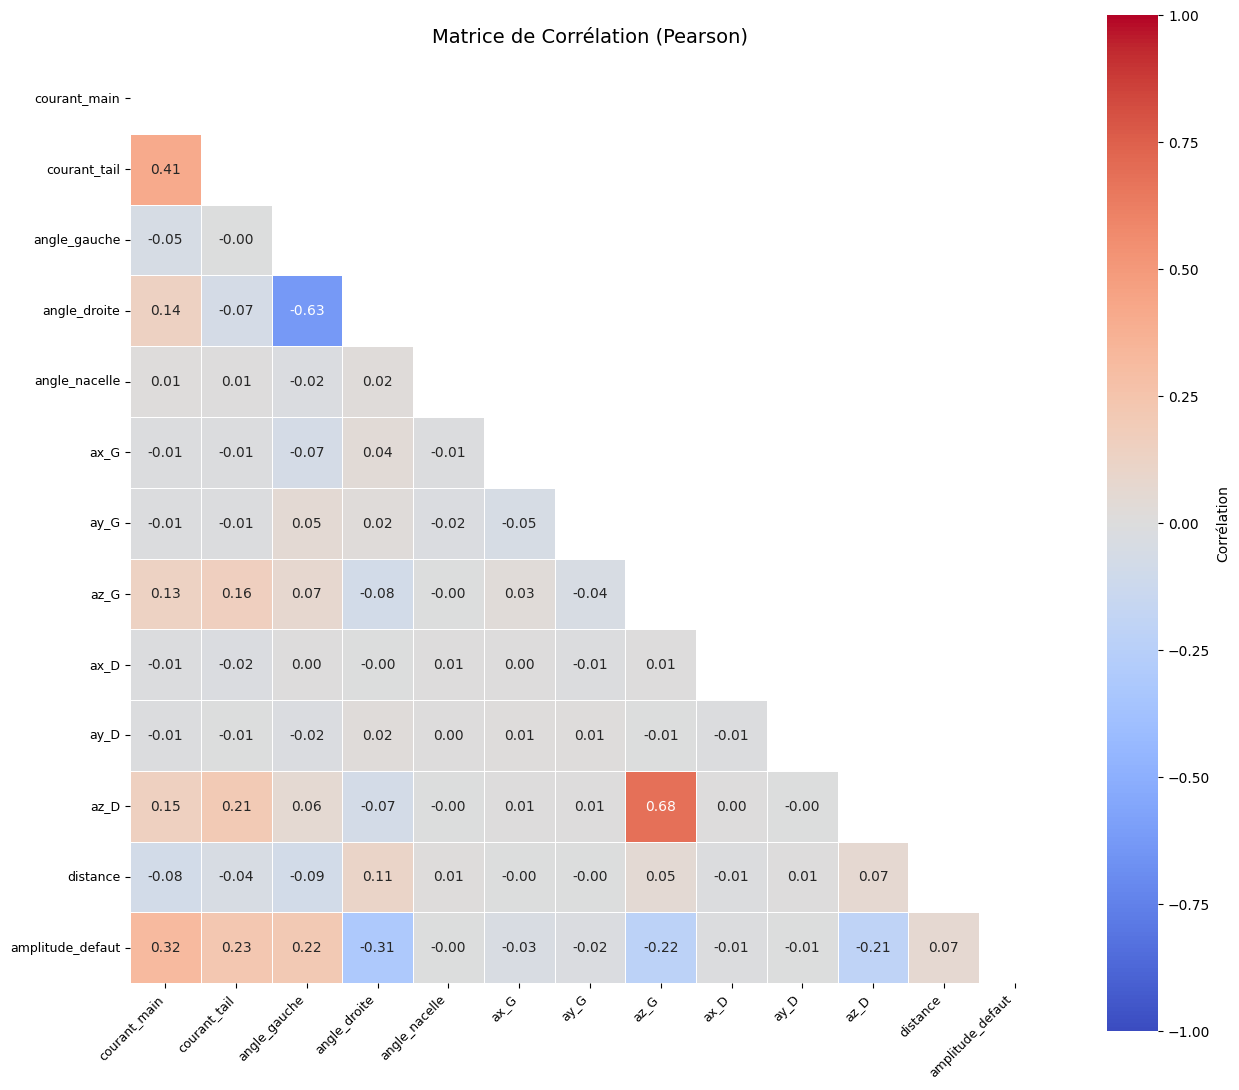


 Aucune paire fortement corrélée (seuil |r| ≥ 0.7).
Scatter matrix limitée aux 8 variables à plus forte variance.


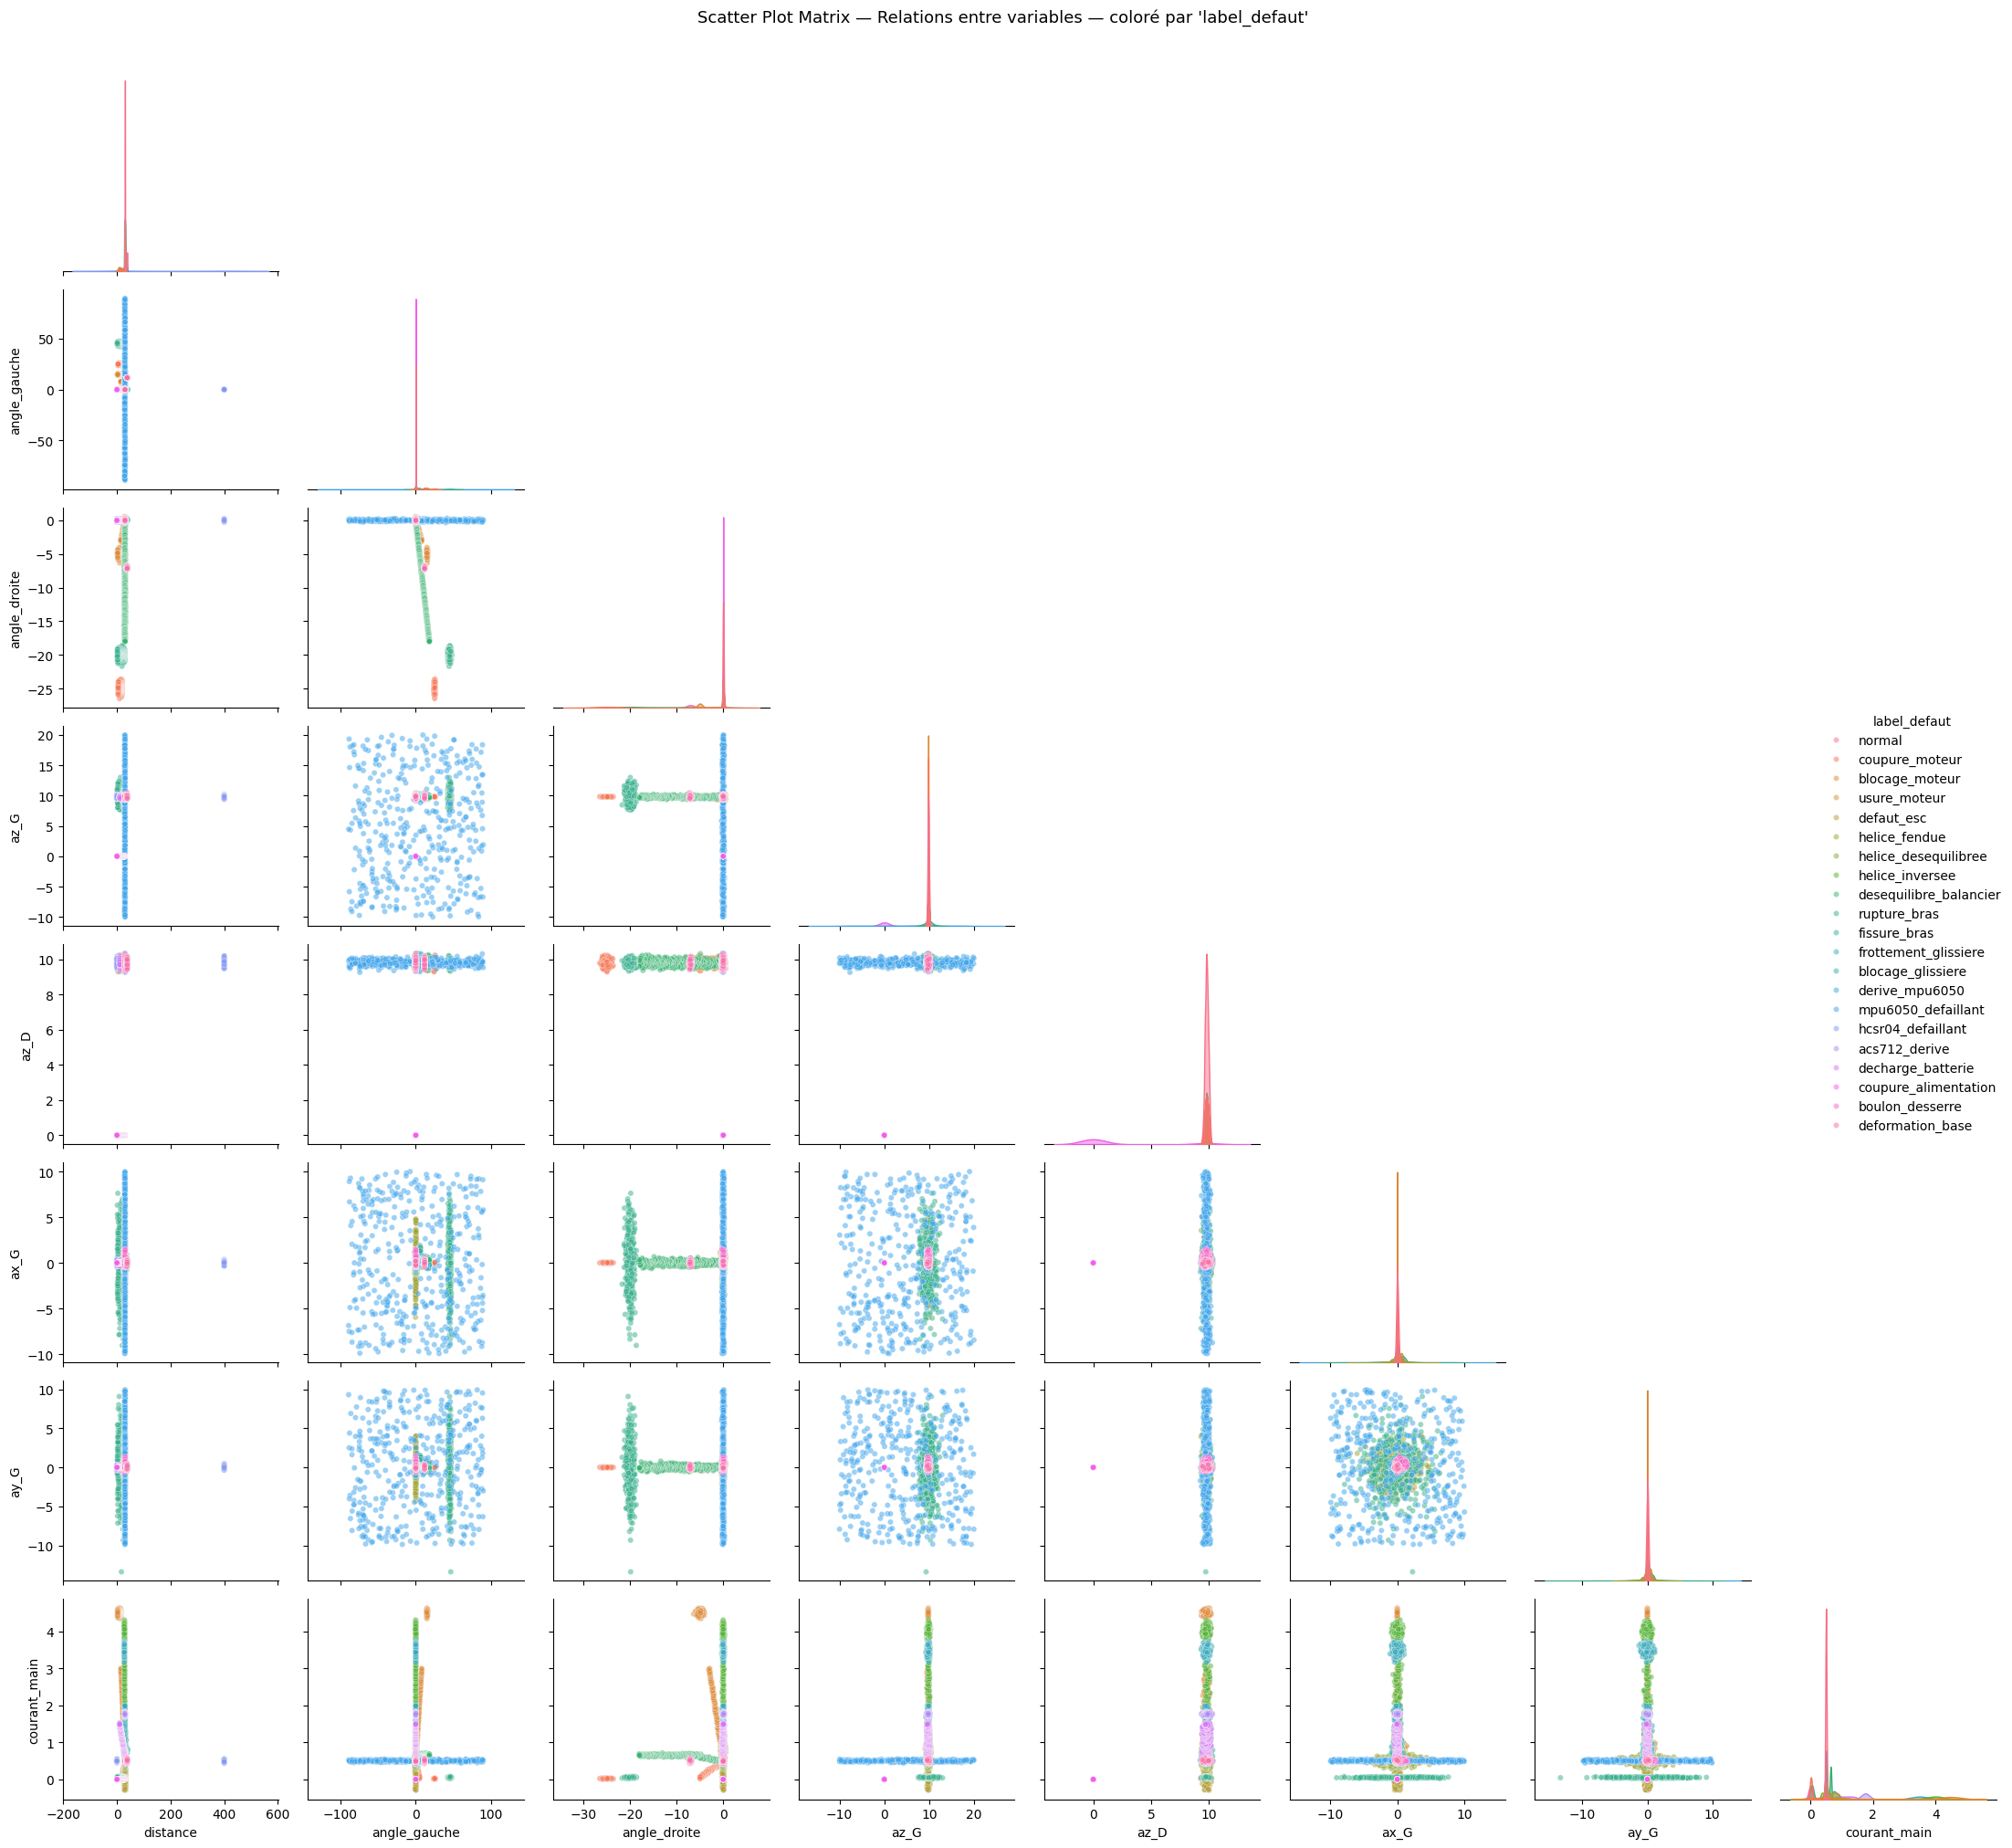

In [ ]:
def correlation_matrix(df: pd.DataFrame, target_cols: list = None,method: str = "pearson") -> None:
    num_df = df.select_dtypes(include=[np.number])
    if num_df.shape[1] < 2:
        print("Pas assez de variables numériques pour une matrice de corrélation.")
        return
    corr = num_df.corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(max(8, corr.shape[1]), max(6, corr.shape[0])))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.4,cbar_kws={"shrink": 0.8, "label": "Corrélation"})
    plt.title(f"Matrice de Corrélation ({method.capitalize()})", fontsize=14, pad=15)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(f"correlation_{method}.png", dpi=150, bbox_inches="tight")
    plt.show()
    threshold = 0.7
    strong = []
    for c1, c2 in combinations(corr.columns, 2):
        val = corr.loc[c1, c2]
        if abs(val) >= threshold:
            strong.append((c1, c2, round(val, 3)))
    if strong:
        print(f"Paires fortement corrélées (|r| ≥ {threshold}) — risque de multicolinéarité :")
        for c1, c2, val in sorted(strong, key=lambda x: -abs(x[2])):
            print(f"   {c1}  ↔  {c2}  :  r = {val}")
    else:
        print(f"\n Aucune paire fortement corrélée (seuil |r| ≥ {threshold}).")
def plot_scatter_matrix(df: pd.DataFrame, target_cols: list = None,max_cols: int = 8) -> None:
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_cols:
        num_cols = [col for col in num_cols if col not in target_cols]
    if len(num_cols) > max_cols:
        variances = df[num_cols].var().sort_values(ascending=False)
        num_cols = variances.index[:max_cols].tolist()
        print(f"Scatter matrix limitée aux {max_cols} variables à plus forte variance.")
    subset = df[num_cols].copy()
    hue_col = None
    if target_cols:
        for tc in target_cols:
            if tc in df.columns:
                subset[tc] = df[tc]
                if df[tc].dtype in [np.float64, np.int64]:
                    subset["_target_cat"] = pd.qcut(df[tc], q=3, labels=["Bas", "Moyen", "Élevé"], duplicates="drop")
                    hue_col = "_target_cat"
                else:
                    hue_col = tc
                break
    pair_kws = dict(alpha=0.5, s=20)
    diag_kws = dict(fill=True, alpha=0.5)
    g = sns.pairplot( subset,hue=hue_col,diag_kind="kde",plot_kws=pair_kws,diag_kws=diag_kws,corner=True)
    hue_info = f" — coloré par '{hue_col}'" if hue_col else ""
    g.figure.suptitle(f"Scatter Plot Matrix — Relations entre variables{hue_info}", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig("scatter_matrix.png", dpi=120, bbox_inches="tight")
    plt.show()
corr_method = "pearson"
correlation_matrix(df, target_cols=target_cols, method=corr_method)
plot_scatter_matrix(df, target_cols=target_cols)

In [ ]:
target_cols

['label_defaut', 'amplitude_defaut', 'localisation_defaut']

**Prétraitement des Données**

**1. Gestion des valeurs manquantes**

In [ ]:
def handle_missing_values(df: pd.DataFrame,drop_threshold: float = 0.5) -> pd.DataFrame:
    df = df.copy()
    missing_pct = df.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > drop_threshold].index.tolist()
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)
        print(f"[4.1 - Manquants] Colonnes supprimées (>{drop_threshold*100:.0f}% NaN) : {cols_to_drop}")
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        if df[col].isnull().sum() == 0:
            continue
        skewness = df[col].skew()
        strategy = 'median' if abs(skewness) > 1 else 'mean'
        imputer = SimpleImputer(strategy=strategy)
        df[[col]] = imputer.fit_transform(df[[col]])
        print(f"[4.1 - Manquants] '{col}' → imputation par {strategy} (skewness={skewness:.2f})")
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if cat_cols:
        imputer_cat = SimpleImputer(strategy='most_frequent')
        df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])
        print(f"[4.1 - Manquants] Colonnes catégorielles → imputation par mode : {cat_cols}")
    return df
df = df.drop('timestamp', axis=1)
handle_missing_values(df, drop_threshold=0.5)

[4.1 - Manquants] Colonnes catégorielles → imputation par mode : ['label_defaut', 'localisation_defaut']


,courant_main,courant_tail,angle_gauche,angle_droite,angle_nacelle,ax_G,ay_G,az_G,ax_D,ay_D,az_D,distance,label_defaut,amplitude_defaut,localisation_defaut
0,0.509934,0.486496,-0.086349,-0.111408,-0.001651,-0.101774,0.176222,9.776364,0.131896,0.048275,9.862243,29.321184,normal,0.0,aucune
1,0.497235,0.497110,-0.003120,-0.063093,-0.025183,-0.045825,-0.281847,9.778375,0.005896,-0.117204,9.852499,29.936605,normal,0.0,aucune
2,0.512954,0.484152,0.001802,-0.094206,-0.008619,-0.089607,-0.049169,10.145314,-0.136849,0.103703,9.669522,30.576884,normal,0.0,aucune
3,0.530461,0.493841,0.047263,-0.054800,0.035737,0.016563,-0.006249,9.931397,-0.069375,-0.088554,9.896938,30.034326,normal,0.0,aucune
4,0.495317,0.462128,-0.136686,-0.021415,0.063893,0.179577,0.002386,10.182098,0.051428,0.112433,9.586488,30.469544,normal,0.0,aucune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.491608,0.514717,11.781888,-7.045082,-0.056041,0.054145,0.113541,9.876592,0.111910,-0.117005,9.530947,39.017862,deformation_base,0.5,base_socle
11996,0.490422,0.500703,11.752482,-6.918732,0.137529,0.085241,-0.062705,9.788223,0.241210,-0.170446,9.706883,38.178056,deformation_base,0.5,base_socle
11997,0.502118,0.473641,11.628092,-7.160948,-0.040418,0.055148,-0.204149,10.029153,-0.197611,0.062817,10.028697,37.538567,deformation_base,0.5,base_socle
11998,0.505240,0.518507,11.724775,-7.108138,0.120975,0.084899,0.347144,9.590172,0.079580,0.120209,9.942867,38.470688,deformation_base,0.5,base_socle


**2. Suppression ou traitement des valeurs aberrantes**

In [ ]:
def handle_outliers( df: pd.DataFrame,cols: list = None,factor: float = 1.5,strategy: str = 'remove') -> pd.DataFrame:
    """
    Détecte les outliers via IQR (boxplot) et les supprime
    ou les remplace par une mesure représentative (moyenne/médiane).

    Args:
        df: DataFrame d'entrée
        cols: colonnes numériques à traiter (toutes si None)
        factor: multiplicateur IQR (1.5 par défaut)
        strategy: 'remove', 'replace_mean' ou 'replace_median'

    Returns:
        DataFrame traité
    """
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    n_before = len(df)

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        outlier_mask = (df[col] < lower) | (df[col] > upper)
        n_outliers = outlier_mask.sum()

        if n_outliers == 0:
            continue

        if strategy == 'remove':
            df = df[~outlier_mask]
            print(f"[4.2 - Outliers] '{col}' → {n_outliers} lignes supprimées")

        elif strategy == 'replace_mean':
            df.loc[outlier_mask, col] = df.loc[~outlier_mask, col].mean()
            print(f"[4.2 - Outliers] '{col}' → {n_outliers} valeurs remplacées par la moyenne")

        elif strategy == 'replace_median':
            df.loc[outlier_mask, col] = df.loc[~outlier_mask, col].median()
            print(f"[4.2 - Outliers] '{col}' → {n_outliers} valeurs remplacées par la médiane")

    if strategy == 'remove':
        print(f"[4.2 - Outliers] Total : {n_before - len(df)} lignes supprimées. Restantes : {len(df)}")

    return df
df = handle_outliers(df, strategy='replace_median')

[4.2 - Outliers] 'courant_main' → 3346 valeurs remplacées par la médiane
[4.2 - Outliers] 'courant_tail' → 2256 valeurs remplacées par la médiane
[4.2 - Outliers] 'angle_gauche' → 2475 valeurs remplacées par la médiane
[4.2 - Outliers] 'angle_droite' → 2297 valeurs remplacées par la médiane
[4.2 - Outliers] 'angle_nacelle' → 400 valeurs remplacées par la médiane
[4.2 - Outliers] 'ax_G' → 1766 valeurs remplacées par la médiane
[4.2 - Outliers] 'ay_G' → 1698 valeurs remplacées par la médiane
[4.2 - Outliers] 'az_G' → 1130 valeurs remplacées par la médiane
[4.2 - Outliers] 'ax_D' → 270 valeurs remplacées par la médiane
[4.2 - Outliers] 'ay_D' → 286 valeurs remplacées par la médiane
[4.2 - Outliers] 'az_D' → 444 valeurs remplacées par la médiane
[4.2 - Outliers] 'distance' → 2718 valeurs remplacées par la médiane


**3. Normalisation ou standardisation des données**

In [ ]:
def scale_features( df: pd.DataFrame,cols: list = None,method: str = 'compare'    "'minmax' | 'zscore' | 'compare'" ) -> pd.DataFrame:
    """
    Normalise (Min-Max) ou standardise (Z-score) les variables numériques.
    En mode 'compare', teste les deux méthodes et sélectionne automatiquement
    celle dont la distribution est la plus centrée (std la plus proche de 1).

    Args:
        df: DataFrame d'entrée
        cols: colonnes à scaler (toutes numériques si None)
        method: 'minmax', 'zscore' ou 'compare'

    Returns:
        DataFrame avec variables mises à l'échelle
    """
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if method == 'minmax':
        scaler = MinMaxScaler()
        df[cols] = scaler.fit_transform(df[cols])
        print(f"[4.3 - Scaling] Normalisation Min-Max appliquée sur : {cols}")

    elif method == 'zscore':
        scaler = StandardScaler()
        df[cols] = scaler.fit_transform(df[cols])
        print(f"[4.3 - Scaling] Standardisation Z-score appliquée sur : {cols}")

    elif method == 'compare':
        # Teste les deux méthodes et choisit la plus adaptée par colonne
        for col in cols:
            data = df[[col]].dropna()

            mm = MinMaxScaler().fit_transform(data)
            zs = StandardScaler().fit_transform(data)

            # Critère : std la plus proche de 1 → meilleure dispersion
            std_mm = np.std(mm)
            std_zs = np.std(zs)

            if abs(std_zs - 1) <= abs(std_mm - 1):
                df[col] = StandardScaler().fit_transform(df[[col]])
                chosen = 'Z-score'
            else:
                df[col] = MinMaxScaler().fit_transform(df[[col]])
                chosen = 'Min-Max'

            print(f"[4.3 - Scaling] '{col}' → {chosen} sélectionné "
                  f"(std Min-Max={std_mm:.3f}, std Z-score={std_zs:.3f})")

    return df
df = scale_features(df, method='compare')

[4.3 - Scaling] 'courant_main' → Z-score sélectionné (std Min-Max=0.115, std Z-score=1.000)
[4.3 - Scaling] 'courant_tail' → Z-score sélectionné (std Min-Max=0.126, std Z-score=1.000)
[4.3 - Scaling] 'angle_gauche' → Z-score sélectionné (std Min-Max=0.122, std Z-score=1.000)
[4.3 - Scaling] 'angle_droite' → Z-score sélectionné (std Min-Max=0.120, std Z-score=1.000)
[4.3 - Scaling] 'angle_nacelle' → Z-score sélectionné (std Min-Max=0.183, std Z-score=1.000)
[4.3 - Scaling] 'ax_G' → Z-score sélectionné (std Min-Max=0.162, std Z-score=1.000)
[4.3 - Scaling] 'ay_G' → Z-score sélectionné (std Min-Max=0.164, std Z-score=1.000)
[4.3 - Scaling] 'az_G' → Z-score sélectionné (std Min-Max=0.161, std Z-score=1.000)
[4.3 - Scaling] 'ax_D' → Z-score sélectionné (std Min-Max=0.181, std Z-score=1.000)
[4.3 - Scaling] 'ay_D' → Z-score sélectionné (std Min-Max=0.181, std Z-score=1.000)
[4.3 - Scaling] 'az_D' → Z-score sélectionné (std Min-Max=0.169, std Z-score=1.000)
[4.3 - Scaling] 'distance' → Z-scor

**Feature Engineering**

**1. Features physiques**

In [ ]:
import pandas as pd
import numpy as np

def add_physical_features(df: pd.DataFrame,  col_main: str = 'courant_main',col_tail: str = 'courant_tail') -> pd.DataFrame:
    """
    Construit les features physiques à partir des relations entre capteurs.

    6.1.1 Différence de courant : ΔI = |courant_main - courant_tail|
          Intérêt : Détection d'un déséquilibre du système,
                    Indicateur précoce d'un dysfonctionnement moteur

    6.1.2 Ratio des courants : R_I = courant_main / courant_tail
          Intérêt : Normalisation de déséquilibre

    6.1.3 Norme accélération gauche : ||a_G|| = sqrt(ax_G² + ay_G² + az_G²)
          Intérêt : Intensité vibratoire du côté gauche

    6.1.4 Norme accélération droite : ||a_D|| = sqrt(ax_D² + ay_D² + az_D²)
          Intérêt : Intensité vibratoire du côté droit

    6.1.5 Différence de norme accélération : Δ||a|| = | ||a_G|| - ||a_D|| |
          Intérêt : Déséquilibre vibratoire gauche/droite

    6.1.6 Différence d'angles : Δangle = |angle_gauche - angle_droite|
          Intérêt : Déséquilibre angulaire entre les deux côtés

    Args:
        df       : DataFrame d'entrée
        col_main : nom de la colonne courant main rotor
        col_tail : nom de la colonne courant tail rotor

    Returns:
        DataFrame enrichi
    """
    df = df.copy()
     # 6.1.1 — Différence de courant
    if col_main in df.columns and col_tail in df.columns:
        df['delta_I'] = (df[col_main] - df[col_tail]).abs()
        print(f"[6.1.1 - Physique] 'delta_I' = |{col_main} - {col_tail}|")

        # 6.1.2 — Ratio des courants
        df['ratio_I'] = df[col_main] / df[col_tail].replace(0, np.nan)
        print(f"[6.1.2 - Physique] 'ratio_I' = {col_main} / {col_tail}")
    else:
        print(f"[6.1 - Physique] Colonnes '{col_main}' ou '{col_tail}' introuvables, ignorées.")

    # 6.1.3 — Norme accélération gauche
    if all(c in df.columns for c in ['ax_G', 'ay_G', 'az_G']):
        df['norm_accel_G'] = np.sqrt(df['ax_G']**2 + df['ay_G']**2 + df['az_G']**2)
        print("[6.1.3 - Physique] 'norm_accel_G' = sqrt(ax_G² + ay_G² + az_G²)")
    else:
        print("[6.1.3 - Physique] Colonnes ax_G / ay_G / az_G introuvables, ignorées.")

    # 6.1.4 — Norme accélération droite
    if all(c in df.columns for c in ['ax_D', 'ay_D', 'az_D']):
        df['norm_accel_D'] = np.sqrt(df['ax_D']**2 + df['ay_D']**2 + df['az_D']**2)
        print("[6.1.4 - Physique] 'norm_accel_D' = sqrt(ax_D² + ay_D² + az_D²)")
    else:
        print("[6.1.4 - Physique] Colonnes ax_D / ay_D / az_D introuvables, ignorées.")

    # 6.1.5 — Différence de norme accélération
    if 'norm_accel_G' in df.columns and 'norm_accel_D' in df.columns:
        df['delta_norm_accel'] = (df['norm_accel_G'] - df['norm_accel_D']).abs()
        print("[6.1.5 - Physique] 'delta_norm_accel' = |norm_accel_G - norm_accel_D|")

    # 6.1.6 — Différence d'angles gauche/droite
    if 'angle_gauche' in df.columns and 'angle_droite' in df.columns:
        df['delta_angle'] = (df['angle_gauche'] - df['angle_droite']).abs()
        print("[6.1.6 - Physique] 'delta_angle' = |angle_gauche - angle_droite|")
    else:
        print("[6.1.6 - Physique] Colonnes 'angle_gauche' ou 'angle_droite' introuvables, ignorées.")

    return df


# ── Appel ──
df = add_physical_features(df,col_main='courant_main',col_tail='courant_tail')

[6.1.1 - Physique] 'delta_I' = |courant_main - courant_tail|
[6.1.2 - Physique] 'ratio_I' = courant_main / courant_tail
[6.1.3 - Physique] 'norm_accel_G' = sqrt(ax_G² + ay_G² + az_G²)
[6.1.4 - Physique] 'norm_accel_D' = sqrt(ax_D² + ay_D² + az_D²)
[6.1.5 - Physique] 'delta_norm_accel' = |norm_accel_G - norm_accel_D|
[6.1.6 - Physique] 'delta_angle' = |angle_gauche - angle_droite|


In [ ]:
df.head()

,courant_main,courant_tail,angle_gauche,angle_droite,angle_nacelle,ax_G,ay_G,az_G,ax_D,ay_D,...,distance,label_defaut,amplitude_defaut,localisation_defaut,delta_I,ratio_I,norm_accel_G,norm_accel_D,delta_norm_accel,delta_angle
0,-0.269495,-0.753019,-0.353810,-1.190315,-0.012123,-0.683996,0.746267,-0.245446,0.888739,0.341079,...,-0.381351,normal,-1.66606,aucune,0.483524,0.357886,1.041638,1.017586,0.024052,0.836505
1,-0.373264,-0.171982,-0.288496,-0.670784,-0.292172,-0.410495,-1.632588,-0.230965,0.038068,-0.793836,...,0.213741,normal,-1.66606,aucune,0.201282,2.170371,1.699174,0.846927,0.852248,0.382288
2,-0.244822,-0.881391,-0.284634,-1.005341,-0.095044,-0.624519,-0.424240,2.411458,-0.925659,0.721225,...,0.832869,normal,-1.66606,aucune,0.636569,0.277768,2.526883,1.518251,1.008632,0.720708
3,-0.101772,-0.350941,-0.248958,-0.581604,0.432834,-0.105520,-0.201346,0.870984,-0.470117,-0.597348,...,0.308233,normal,-1.66606,aucune,0.249168,0.289999,0.900160,0.967014,0.066854,0.332646
4,-0.388934,-2.087126,-0.393312,-0.222620,0.767925,0.691355,-0.156501,2.676346,0.345469,0.781097,...,0.729075,normal,-1.66606,aucune,1.698192,0.186349,2.768626,1.755177,1.013449,0.170692


In [ ]:
df.dtypes

,0
courant_main,float64
courant_tail,float64
angle_gauche,float64
angle_droite,float64
angle_nacelle,float64
ax_G,float64
ay_G,float64
az_G,float64
ax_D,float64
ay_D,float64


**2. Features Temporelles (fenêtres glissantes)**

In [ ]:
def add_temporal_features(df: pd.DataFrame,cols: list = None,window: int = 10) -> pd.DataFrame:
    """
    Extrait des statistiques sur fenêtres glissantes de taille N.

    6.2.1 RMS   : sqrt(1/N * Σ xi²)               — Énergie du signal
    6.2.2 Variance σ² = 1/N * Σ(xi - x̄)²          — Mesure de dispersion
    6.2.3 Moyenne glissante μ = 1/N * Σxi            — Lissage du signal
    6.2.4 Écart-type σ = sqrt(σ²)                   — Sensible aux anomalies
    6.2.5 Maximum et Minimum                         — Détection de pics

    Colonnes traitées (brutes uniquement) :
        courant_main, courant_tail,
        angle_gauche, angle_droite, angle_nacelle,
        ax_G, ay_G, az_G,
        ax_D, ay_D, az_D,
        distance

    Args:
        df    : DataFrame d'entrée (ordonné temporellement)
        cols  : colonnes numériques à traiter (toutes si None)
        window: taille N de la fenêtre glissante

    Returns:
        DataFrame enrichi avec les statistiques glissantes
    """
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    for col in cols:
        s = df[col]

        # 6.2.1 RMS — sqrt(1/N * Σ xi²)
        df[f'rms_{col}'] = (
            s.pow(2)
             .rolling(window=window, min_periods=1)
             .mean()
             .pow(0.5)
        )
        print(f"[6.2.1 - RMS]      'rms_{col}'  (fenêtre={window})")

        # 6.2.2 Variance glissante
        df[f'var_{col}'] = s.rolling(window=window, min_periods=1).var()
        print(f"[6.2.2 - Variance] 'var_{col}'  (fenêtre={window})")

        # 6.2.3 Moyenne glissante
        df[f'mean_{col}'] = s.rolling(window=window, min_periods=1).mean()
        print(f"[6.2.3 - Moyenne]  'mean_{col}' (fenêtre={window})")

        # 6.2.4 Écart-type glissant  σ = sqrt(σ²)
        df[f'std_{col}'] = s.rolling(window=window, min_periods=1).std()
        print(f"[6.2.4 - Écart]    'std_{col}'  (fenêtre={window})")

        # 6.2.5 Maximum et Minimum glissants
        df[f'max_{col}'] = s.rolling(window=window, min_periods=1).max()
        df[f'min_{col}'] = s.rolling(window=window, min_periods=1).min()
        print(f"[6.2.5 - Max/Min]  'max_{col}', 'min_{col}' (fenêtre={window})")

    return df


# ── Appel ──
# Colonnes brutes (numériques) uniquement — avant tout enrichissement
BASE_COLS = ['courant_main', 'courant_tail','angle_gauche', 'angle_droite', 'angle_nacelle','ax_G', 'ay_G', 'az_G','ax_D', 'ay_D', 'az_D','distance']

# Ne garder que celles effectivement présentes dans le DataFrame
base_cols = [c for c in BASE_COLS if c in df.columns]

df = add_temporal_features(
    df,
    cols=base_cols,
    window=10
)

[6.2.1 - RMS]      'rms_courant_main'  (fenêtre=10)
[6.2.2 - Variance] 'var_courant_main'  (fenêtre=10)
[6.2.3 - Moyenne]  'mean_courant_main' (fenêtre=10)
[6.2.4 - Écart]    'std_courant_main'  (fenêtre=10)
[6.2.5 - Max/Min]  'max_courant_main', 'min_courant_main' (fenêtre=10)
[6.2.1 - RMS]      'rms_courant_tail'  (fenêtre=10)
[6.2.2 - Variance] 'var_courant_tail'  (fenêtre=10)
[6.2.3 - Moyenne]  'mean_courant_tail' (fenêtre=10)
[6.2.4 - Écart]    'std_courant_tail'  (fenêtre=10)
[6.2.5 - Max/Min]  'max_courant_tail', 'min_courant_tail' (fenêtre=10)
[6.2.1 - RMS]      'rms_angle_gauche'  (fenêtre=10)
[6.2.2 - Variance] 'var_angle_gauche'  (fenêtre=10)
[6.2.3 - Moyenne]  'mean_angle_gauche' (fenêtre=10)
[6.2.4 - Écart]    'std_angle_gauche'  (fenêtre=10)
[6.2.5 - Max/Min]  'max_angle_gauche', 'min_angle_gauche' (fenêtre=10)
[6.2.1 - RMS]      'rms_angle_droite'  (fenêtre=10)
[6.2.2 - Variance] 'var_angle_droite'  (fenêtre=10)
[6.2.3 - Moyenne]  'mean_angle_droite' (fenêtre=10)
[6.2.4 

In [ ]:
df.head()

,courant_main,courant_tail,angle_gauche,angle_droite,angle_nacelle,ax_G,ay_G,az_G,ax_D,ay_D,...,mean_az_D,std_az_D,max_az_D,min_az_D,rms_distance,var_distance,mean_distance,std_distance,max_distance,min_distance
0,-0.269495,-0.753019,-0.353810,-1.190315,-0.012123,-0.683996,0.746267,-0.245446,0.888739,0.341079,...,0.359568,NaN,0.359568,0.359568,0.381351,NaN,-0.381351,NaN,-0.381351,-0.381351
1,-0.373264,-0.171982,-0.288496,-0.670784,-0.292172,-0.410495,-1.632588,-0.230965,0.038068,-0.793836,...,0.326123,0.047299,0.359568,0.292678,0.309123,0.177067,-0.083805,0.420793,0.213741,-0.381351
2,-0.244822,-0.881391,-0.284634,-1.005341,-0.095044,-0.624519,-0.424240,2.411458,-0.925659,0.721225,...,-0.103707,0.745238,0.359568,-0.963367,0.543073,0.368630,0.221753,0.607149,0.832869,-0.381351
3,-0.101772,-0.350941,-0.248958,-0.581604,0.432834,-0.105520,-0.201346,0.870984,-0.470117,-0.597348,...,0.071652,0.702322,0.597730,-0.963367,0.494922,0.247623,0.243373,0.497618,0.832869,-0.381351
4,-0.388934,-2.087126,-0.393312,-0.222620,0.767925,0.691355,-0.156501,2.676346,0.345469,0.781097,...,-0.249349,0.940826,0.597730,-1.533357,0.549789,0.232899,0.340513,0.482596,0.832869,-0.381351


In [ ]:
df.dtypes

,0
courant_main,float64
courant_tail,float64
angle_gauche,float64
angle_droite,float64
angle_nacelle,float64
...,...
var_distance,float64
mean_distance,float64
std_distance,float64
max_distance,float64


**3. Features Dynamiques**

In [ ]:
def add_dynamic_features(
    df: pd.DataFrame,
    cols: list = None,
    slope_window: int = 5
) -> pd.DataFrame:
    """
    Capture l'évolution temporelle du système.

    6.3.1 Dérivée temporelle  x'(t) = x(t) - x(t-1)
          Intérêt : Détection de changements brusques,
                    Identification des transitions vers un défaut

    6.3.2 Pente (tendance)    x(t) = at + b
          Intérêt : Détection de dérives progressives,
                    Indicateur de pré-défaut

    6.3.3 Seconde dérivée     x''(t) = x(t) - 2x(t-1) + x(t-2)
          Intérêt : Détection de changements rapides,
                    Analyse de la dynamique du système

    Colonnes traitées (brutes uniquement) :
        courant_main, courant_tail,
        angle_gauche, angle_droite, angle_nacelle,
        ax_G, ay_G, az_G,
        ax_D, ay_D, az_D,
        distance

    Args:
        df          : DataFrame d'entrée
        cols        : colonnes numériques (toutes si None)
        slope_window: taille de fenêtre pour la régression linéaire

    Returns:
        DataFrame enrichi avec dérivées et pentes
    """
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    t = np.arange(slope_window).reshape(-1, 1)

    for col in cols:
        s = df[col]

        # 6.3.1 Première dérivée discrète : x'(t) = x(t) - x(t-1)
        df[f'deriv1_{col}'] = s.diff(1)
        print(f"[6.3.1 - Dérivée 1] 'deriv1_{col}'")

        # 6.3.2 Pente locale par régression linéaire glissante
        slopes = [np.nan] * (slope_window - 1)
        for i in range(slope_window - 1, len(df)):
            y = s.iloc[i - slope_window + 1: i + 1].values
            if np.isnan(y).any():
                slopes.append(np.nan)
            else:
                reg = LinearRegression().fit(t, y)
                slopes.append(reg.coef_[0])
        df[f'slope_{col}'] = slopes
        print(f"[6.3.2 - Pente]     'slope_{col}' (fenêtre={slope_window})")

        # 6.3.3 Seconde dérivée : x''(t) = x(t) - 2x(t-1) + x(t-2)
        df[f'deriv2_{col}'] = s.diff(1).diff(1)
        print(f"[6.3.3 - Dérivée 2] 'deriv2_{col}'")

    return df


# ── Appel ──
# Colonnes brutes (numériques) uniquement — avant tout enrichissement
BASE_COLS = [
    'courant_main', 'courant_tail',
    'angle_gauche', 'angle_droite', 'angle_nacelle',
    'ax_G', 'ay_G', 'az_G',
    'ax_D', 'ay_D', 'az_D',
    'distance'
]

# Ne garder que celles effectivement présentes dans le DataFrame
base_cols = [c for c in BASE_COLS if c in df.columns]

df = add_dynamic_features(
    df,
    cols=base_cols,
    slope_window=5
)

[6.3.1 - Dérivée 1] 'deriv1_courant_main'
[6.3.2 - Pente]     'slope_courant_main' (fenêtre=5)
[6.3.3 - Dérivée 2] 'deriv2_courant_main'
[6.3.1 - Dérivée 1] 'deriv1_courant_tail'
[6.3.2 - Pente]     'slope_courant_tail' (fenêtre=5)
[6.3.3 - Dérivée 2] 'deriv2_courant_tail'
[6.3.1 - Dérivée 1] 'deriv1_angle_gauche'
[6.3.2 - Pente]     'slope_angle_gauche' (fenêtre=5)
[6.3.3 - Dérivée 2] 'deriv2_angle_gauche'
[6.3.1 - Dérivée 1] 'deriv1_angle_droite'
[6.3.2 - Pente]     'slope_angle_droite' (fenêtre=5)
[6.3.3 - Dérivée 2] 'deriv2_angle_droite'
[6.3.1 - Dérivée 1] 'deriv1_angle_nacelle'
[6.3.2 - Pente]     'slope_angle_nacelle' (fenêtre=5)
[6.3.3 - Dérivée 2] 'deriv2_angle_nacelle'
[6.3.1 - Dérivée 1] 'deriv1_ax_G'
[6.3.2 - Pente]     'slope_ax_G' (fenêtre=5)
[6.3.3 - Dérivée 2] 'deriv2_ax_G'
[6.3.1 - Dérivée 1] 'deriv1_ay_G'
[6.3.2 - Pente]     'slope_ay_G' (fenêtre=5)
[6.3.3 - Dérivée 2] 'deriv2_ay_G'
[6.3.1 - Dérivée 1] 'deriv1_az_G'
[6.3.2 - Pente]     'slope_az_G' (fenêtre=5)
[6.3.3 

In [ ]:
df.head()

,courant_main,courant_tail,angle_gauche,angle_droite,angle_nacelle,ax_G,ay_G,az_G,ax_D,ay_D,...,deriv2_ax_D,deriv1_ay_D,slope_ay_D,deriv2_ay_D,deriv1_az_D,slope_az_D,deriv2_az_D,deriv1_distance,slope_distance,deriv2_distance
0,-0.269495,-0.753019,-0.353810,-1.190315,-0.012123,-0.683996,0.746267,-0.245446,0.888739,0.341079,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.373264,-0.171982,-0.288496,-0.670784,-0.292172,-0.410495,-1.632588,-0.230965,0.038068,-0.793836,...,NaN,-1.134915,NaN,NaN,-0.066891,NaN,NaN,0.595092,NaN,NaN
2,-0.244822,-0.881391,-0.284634,-1.005341,-0.095044,-0.624519,-0.424240,2.411458,-0.925659,0.721225,...,-0.113055,1.515061,NaN,2.649976,-1.256044,NaN,-1.189154,0.619128,NaN,0.024036
3,-0.101772,-0.350941,-0.248958,-0.581604,0.432834,-0.105520,-0.201346,0.870984,-0.470117,-0.597348,...,1.419269,-1.318573,NaN,-2.833635,1.561097,NaN,2.817142,-0.524636,NaN,-1.143763
4,-0.388934,-2.087126,-0.393312,-0.222620,0.767925,0.691355,-0.156501,2.676346,0.345469,0.781097,...,0.360044,1.378445,0.107653,2.697019,-2.131088,-0.34808,-3.692185,0.420842,0.231534,0.945477


In [ ]:
for col in df.columns:
    print(col)

courant_main
courant_tail
angle_gauche
angle_droite
angle_nacelle
ax_G
ay_G
az_G
ax_D
ay_D
az_D
distance
label_defaut
amplitude_defaut
localisation_defaut
delta_I
ratio_I
norm_accel_G
norm_accel_D
delta_norm_accel
delta_angle
rms_courant_main
var_courant_main
mean_courant_main
std_courant_main
max_courant_main
min_courant_main
rms_courant_tail
var_courant_tail
mean_courant_tail
std_courant_tail
max_courant_tail
min_courant_tail
rms_angle_gauche
var_angle_gauche
mean_angle_gauche
std_angle_gauche
max_angle_gauche
min_angle_gauche
rms_angle_droite
var_angle_droite
mean_angle_droite
std_angle_droite
max_angle_droite
min_angle_droite
rms_angle_nacelle
var_angle_nacelle
mean_angle_nacelle
std_angle_nacelle
max_angle_nacelle
min_angle_nacelle
rms_ax_G
var_ax_G
mean_ax_G
std_ax_G
max_ax_G
min_ax_G
rms_ay_G
var_ay_G
mean_ay_G
std_ay_G
max_ay_G
min_ay_G
rms_az_G
var_az_G
mean_az_G
std_az_G
max_az_G
min_az_G
rms_ax_D
var_ax_D
mean_ax_D
std_ax_D
max_ax_D
min_ax_D
rms_ay_D
var_ay_D
mean_ay_D
std_a

**4. Features Combinées**

In [ ]:
def add_combined_features(
    df: pd.DataFrame,
    interaction_pairs: list = None,
    thresholds: dict = None
) -> pd.DataFrame:
    """
    6.4 Features combinées
    ─────────────────────────────────────────────────────────────────────

    6.4.1  Interactions entre variables
           Intérêt : Capture des relations non linéaires
                     Amélioration des performances du modèle
           Paires par défaut (issues du document) :
             - courant_main × distance
             - norm_accel_G × var_ax_G   (RMS × variance → accel gauche)
             - norm_accel_D × var_ax_D   (RMS × variance → accel droite)

    6.4.2  Indicateurs de seuil   (Équation 12)
           Feature(t) = 1  si RMS > seuil
                        0  sinon
           Intérêt : Simplification de la détection
                     Interprétabilité industrielle
           Seuil automatique = moyenne de la colonne si non fourni.

    Variables input conservées pour les étapes suivantes :
        - delta_I                          (Différence de courant ΔI)
        - norm_accel_G, norm_accel_D       (RMS des accélérations G et D)
        - var_ax_G, var_ay_G, var_az_G     (Variance accél gauche)
        - var_ax_D, var_ay_D, var_az_D     (Variance accél droite)
        - deriv1_courant_main, ...         (Dérivées temporelles)
        - slope_courant_main,  ...         (Pente)
        - delta_angle                      (Asymétrie angulaire)

    Variables cibles (déjà présentes dans le DataFrame) :
        - label_defaut         (type de défaut)
        - amplitude_defaut     (allant de 0 à 1)
        - localisation_defaut  (où se trouve le défaut)

    Args:
        df               : DataFrame d'entrée
        interaction_pairs: liste de tuples (col_a, col_b) — paires par défaut si None
        thresholds       : dict {colonne: seuil} — moyenne si None

    Returns:
        DataFrame enrichi avec les features combinées
    """
    df = df.copy()

    # ── Vérification des colonnes input retenues (§6.4) ─────────────────
    INPUT_COLS = [
        # Différence de courant ΔI
        'delta_I',
        # RMS des accélérations (norm = norme euclidienne ax/ay/az)
        'norm_accel_G', 'norm_accel_D',
        # Variance des accélérations
        'var_ax_G', 'var_ay_G', 'var_az_G',
        'var_ax_D', 'var_ay_D', 'var_az_D',
        # Dérivées temporelles (ordre 1)
        'deriv1_courant_main', 'deriv1_courant_tail',
        'deriv1_angle_gauche', 'deriv1_angle_droite', 'deriv1_angle_nacelle',
        'deriv1_ax_G', 'deriv1_ay_G', 'deriv1_az_G',
        'deriv1_ax_D', 'deriv1_ay_D', 'deriv1_az_D',
        'deriv1_distance',
        # Pente (slope)
        'slope_courant_main', 'slope_courant_tail',
        'slope_angle_gauche', 'slope_angle_droite', 'slope_angle_nacelle',
        'slope_ax_G', 'slope_ay_G', 'slope_az_G',
        'slope_ax_D', 'slope_ay_D', 'slope_az_D',
        'slope_distance',
        # Asymétrie angulaire
        'delta_angle',
    ]

    TARGET_COLS = ['label_defaut', 'amplitude_defaut', 'localisation_defaut']

    missing_inputs  = [c for c in INPUT_COLS  if c not in df.columns]
    missing_targets = [c for c in TARGET_COLS if c not in df.columns]
    if missing_inputs:
        print(f"[6.4 - Avertissement] Colonnes input manquantes : {missing_inputs}")
    if missing_targets:
        print(f"[6.4 - Avertissement] Colonnes cibles manquantes : {missing_targets}")

    # ── 6.4.1  Interactions ──────────────────────────────────────────────
    # Document : Courantgauche × distance  →  courant_main × distance
    #            RMS × variance            →  norm_accel_G × var_ax_G
    #                                         norm_accel_D × var_ax_D
    if interaction_pairs is None:
        interaction_pairs = [
            ('courant_main',  'distance'),    # Courantgauche × distance
            ('norm_accel_G',  'var_ax_G'),    # RMS × variance (côté gauche)
            ('norm_accel_D',  'var_ax_D'),    # RMS × variance (côté droit)
        ]

    for col_a, col_b in interaction_pairs:
        if col_a in df.columns and col_b in df.columns:
            name = f'{col_a}_x_{col_b}'
            df[name] = df[col_a] * df[col_b]
            print(f"[6.4.1 - Interaction] '{name}' créée")
        else:
            print(
                f"[6.4.1 - Interaction] '{col_a}' ou '{col_b}' introuvable "
                f"dans le DataFrame — paire ignorée."
            )

    # ── 6.4.2  Indicateurs de seuil (Éq. 12) ────────────────────────────
    # Feature = 1 si colonne > seuil, 0 sinon
    # Centré sur les colonnes RMS disponibles + variables input clés
    THRESHOLD_COLS = [
        # RMS — variable principale de l'équation (12)
        'norm_accel_G',       # RMS accélérations côté gauche
        'norm_accel_D',       # RMS accélérations côté droit
        'rms_courant_main',   # RMS courant principal
        'rms_courant_tail',   # RMS courant queue
        'rms_ax_G', 'rms_ay_G', 'rms_az_G',  # RMS accél axes G
        'rms_ax_D', 'rms_ay_D', 'rms_az_D',  # RMS accél axes D
        'rms_angle_gauche', 'rms_angle_droite', 'rms_angle_nacelle',
        'rms_distance',
        # Variance
        'var_ax_G', 'var_ay_G', 'var_az_G',
        'var_ax_D', 'var_ay_D', 'var_az_D',
        'var_courant_main', 'var_courant_tail',
        # Différence de courant ΔI
        'delta_I',
        # Asymétrie angulaire
        'delta_angle',
    ]

    if thresholds is None:
        thresholds = {
            col: df[col].mean()
            for col in THRESHOLD_COLS
            if col in df.columns
        }

    for col, seuil in thresholds.items():
        if col in df.columns:
            feat_name = f'thresh_{col}'
            df[feat_name] = (df[col] > seuil).astype(int)
            print(f"[6.4.2 - Seuil]       '{feat_name}' créée  (seuil = {seuil:.4f})")
        else:
            print(f"[6.4.2 - Seuil]       '{col}' introuvable — ignorée.")

    return df


# ── Appel ────────────────────────────────────────────────────────────────────
df = add_combined_features(
    df,
    interaction_pairs=None,  # paires par défaut : courant_main×distance, norm_accel×var
    thresholds=None           # seuil automatique = moyenne de chaque colonne
)

[6.4.1 - Interaction] 'courant_main_x_distance' créée
[6.4.1 - Interaction] 'norm_accel_G_x_var_ax_G' créée
[6.4.1 - Interaction] 'norm_accel_D_x_var_ax_D' créée
[6.4.2 - Seuil]       'thresh_norm_accel_G' créée  (seuil = 1.4708)
[6.4.2 - Seuil]       'thresh_norm_accel_D' créée  (seuil = 1.5731)
[6.4.2 - Seuil]       'thresh_rms_courant_main' créée  (seuil = 0.6732)
[6.4.2 - Seuil]       'thresh_rms_courant_tail' créée  (seuil = 0.8782)
[6.4.2 - Seuil]       'thresh_rms_ax_G' créée  (seuil = 0.8860)
[6.4.2 - Seuil]       'thresh_rms_ay_G' créée  (seuil = 0.8900)
[6.4.2 - Seuil]       'thresh_rms_az_G' créée  (seuil = 0.9159)
[6.4.2 - Seuil]       'thresh_rms_ax_D' créée  (seuil = 0.9586)
[6.4.2 - Seuil]       'thresh_rms_ay_D' créée  (seuil = 0.9589)
[6.4.2 - Seuil]       'thresh_rms_az_D' créée  (seuil = 0.9615)
[6.4.2 - Seuil]       'thresh_rms_angle_gauche' créée  (seuil = 0.5546)
[6.4.2 - Seuil]       'thresh_rms_angle_droite' créée  (seuil = 0.8529)
[6.4.2 - Seuil]       'thresh_

In [ ]:
df.head()

,courant_main,courant_tail,angle_gauche,angle_droite,angle_nacelle,ax_G,ay_G,az_G,ax_D,ay_D,...,thresh_var_ax_G,thresh_var_ay_G,thresh_var_az_G,thresh_var_ax_D,thresh_var_ay_D,thresh_var_az_D,thresh_var_courant_main,thresh_var_courant_tail,thresh_delta_I,thresh_delta_angle
0,-0.269495,-0.753019,-0.353810,-1.190315,-0.012123,-0.683996,0.746267,-0.245446,0.888739,0.341079,...,0,0,0,0,0,0,0,0,0,0
1,-0.373264,-0.171982,-0.288496,-0.670784,-0.292172,-0.410495,-1.632588,-0.230965,0.038068,-0.793836,...,0,1,0,0,0,0,0,0,0,0
2,-0.244822,-0.881391,-0.284634,-1.005341,-0.095044,-0.624519,-0.424240,2.411458,-0.925659,0.721225,...,0,1,1,0,0,0,0,0,0,0
3,-0.101772,-0.350941,-0.248958,-0.581604,0.432834,-0.105520,-0.201346,0.870984,-0.470117,-0.597348,...,0,1,1,0,0,0,0,0,0,0
4,-0.388934,-2.087126,-0.393312,-0.222620,0.767925,0.691355,-0.156501,2.676346,0.345469,0.781097,...,0,0,1,0,0,0,0,0,1,0


In [ ]:
print(df.dtypes.to_string())

courant_main                float64
courant_tail                float64
angle_gauche                float64
angle_droite                float64
angle_nacelle               float64
ax_G                        float64
ay_G                        float64
az_G                        float64
ax_D                        float64
ay_D                        float64
az_D                        float64
distance                    float64
label_defaut                 object
amplitude_defaut            float64
localisation_defaut          object
delta_I                     float64
ratio_I                     float64
norm_accel_G                float64
norm_accel_D                float64
delta_norm_accel            float64
delta_angle                 float64
rms_courant_main            float64
var_courant_main            float64
mean_courant_main           float64
std_courant_main            float64
max_courant_main            float64
min_courant_main            float64
rms_courant_tail            

**Sélection de Features**

**1. Random Forest**

Dataset chargé : 12000 lignes × 156 colonnes
Cibles         : ['label_defaut', 'amplitude_defaut', 'localisation_defaut']
Cibles présentes : OK


  7.1  FEATURE IMPORTANCE — Random Forest Multi-Output (MDI)
       Cibles simultanées : label_defaut + amplitude_defaut
                            + localisation_defaut

[7.1.1] label_defaut              │ catégorielle                               │ ✓ présente
[7.1.1] amplitude_defaut          │ numérique [0–1] ⚠️  exclue explicitement   │ ✓ présente
[7.1.1] localisation_defaut       │ catégorielle                               │ ✓ présente

[Encodage] 'label_defaut' → classes : ['acs712_derive', 'blocage_glissiere', 'blocage_moteur', 'boulon_desserre', 'coupure_alimentation', 'coupure_moteur', 'decharge_batterie', 'defaut_esc', 'deformation_base', 'derive_mpu6050', 'desequilibre_balancier', 'fissure_bras', 'frottement_glissiere', 'hcsr04_defaillant', 'helice_desequilibree', 'helice_fendue', 'helice_inversee', 'mpu6050_defaillant', 'normal

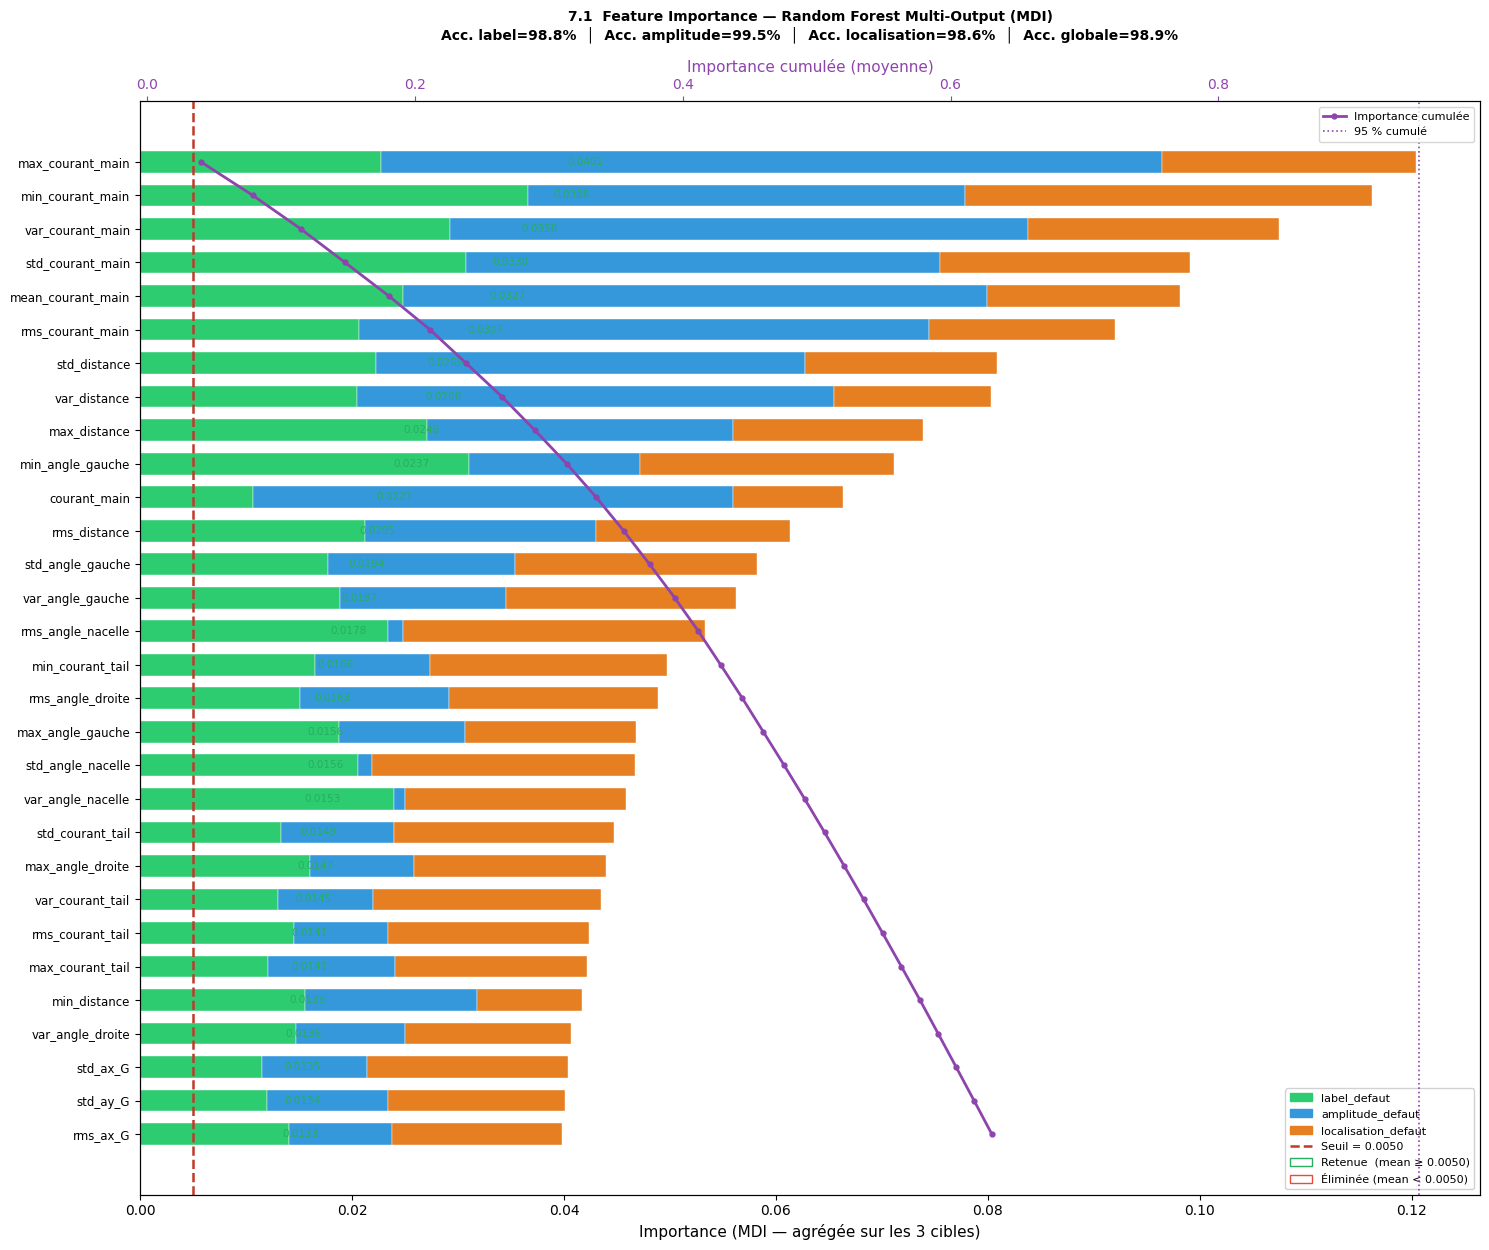


  SECTION 7.1 TERMINÉE — 57 features sélectionnées
  Accuracy globale (3 cibles) : 98.93 %


Features sélectionnées (57) :
--------------------------------------------------------------------------------
  #  Feature                                            Mean     Label      Ampl       Loc
--------------------------------------------------------------------------------
    1. max_courant_main                                0.04014   0.02274   0.07365   0.02403
    2. min_courant_main                                0.03876   0.03658   0.04127   0.03842
    3. var_courant_main                                0.03581   0.02921   0.05461   0.02362
    4. std_courant_main                                0.03304   0.03077   0.04476   0.02358
    5. mean_courant_main                               0.03272   0.02479   0.05512   0.01824
    6. rms_courant_main                                0.03067   0.02068   0.05373   0.01760
    7. std_distance                                    0.02695   

In [ ]:
# =============================================================================
#  SECTION 7 — SÉLECTION DE FEATURES
#  7.1  Random Forest Multi-Output (MDI — Mean Decrease in Impurity)
# =============================================================================
#
#  Objectif : entraîner UN SEUL modèle qui prédit SIMULTANÉMENT :
#    • label_defaut        → type de défaut        (catégorielle)
#    • amplitude_defaut    → amplitude du défaut    (numérique [0–1] → discrétisée)
#    • localisation_defaut → position du défaut     (catégorielle)
#
#  Pourquoi multi-output ?
#    Les 3 cibles sont liées : un défaut a simultanément un type, une amplitude
#    et une localisation. Les entraîner séparément brise cette cohérence et
#    empêche le modèle de capturer les corrélations inter-cibles.
#
#  Après la phase de Feature Engineering, le nombre de variables peut devenir
#  important. Il est donc nécessaire de sélectionner les variables les plus
#  pertinentes afin :
#    • d'améliorer les performances du modèle
#    • de réduire le temps de calcul
#    • d'éviter le surapprentissage (overfitting)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

# ─────────────────────────────────────────────────────────────────────────────
#  CONSTANTES GLOBALES DU PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

RANDOM_STATE = 42

# Les 3 variables cibles du pipeline (§6.4) — combinées dans un seul modèle
# Exclues EXPLICITEMENT des features, car :
#   • label_defaut        → catégorielle
#   • amplitude_defaut    → numérique [0–1] ⚠️ passerait le filtre dtype sinon
#   • localisation_defaut → catégorielle
TARGET_COLS = ["label_defaut", "amplitude_defaut", "localisation_defaut"]

# Métadonnées techniques — jamais des features
META_COLS = {"label_id", "timestamp", "phase"}

# Ensemble complet à exclure avant modélisation
COLS_TO_EXCLUDE = set(TARGET_COLS) | META_COLS


# =============================================================================
#  ENCODAGE DES CIBLES
# =============================================================================

def encode_targets(df: pd.DataFrame) -> tuple:
    """
    Encode les 3 cibles simultanément pour le modèle multi-output.

      • label_defaut        → LabelEncoder direct (catégorielle)
      • amplitude_defaut    → pd.cut → 3 bins → LabelEncoder
                              faible [0–0.33] / moyen [0.33–0.66] / fort [0.66–1.0]
      • localisation_defaut → LabelEncoder direct (catégorielle)

    Returns
    -------
    Y          : DataFrame (n, 3) des cibles encodées
    encoders   : dict {target_col: LabelEncoder} pour décodage ultérieur
    """
    encoders = {}
    Y = pd.DataFrame(index=df.index)

    for col in TARGET_COLS:
        le = LabelEncoder()

        if col == "amplitude_defaut":
            # Numérique continue → discrétisation en 3 classes ordonnées
            binned = pd.cut(
                df[col],
                bins=[0.0, 0.33, 0.66, 1.0],
                labels=["faible", "moyen", "fort"],
                include_lowest=True,
            ).astype(str)
            Y[col] = le.fit_transform(binned)
            print(f"[Encodage] '{col}' → discrétisée : faible[0–0.33] / moyen[0.33–0.66] / fort[0.66–1.0]")
        else:
            Y[col] = le.fit_transform(df[col].astype(str))
            print(f"[Encodage] '{col}' → classes : {list(le.classes_)}")

        encoders[col] = le

    return Y, encoders


# =============================================================================
#  7.1  FEATURE IMPORTANCE — MULTI-OUTPUT
# =============================================================================

def compute_feature_importance_multioutput(
    df: pd.DataFrame,
    importance_threshold: float = 0.005,
    n_estimators: int = 200,
    max_depth: int = None,
    top_n: int = 30,
    plot: bool = True,
    save_png: str = "feature_importance_multioutput.png",
    save_csv: str = "selected_features_multioutput.csv",
) -> tuple:
    """
    7.1 – Sélection de Features par Random Forest Multi-Output (MDI).

    Un seul modèle prédit SIMULTANÉMENT les 3 cibles :
        label_defaut + amplitude_defaut + localisation_defaut

    7.1.1  Principe
           Le modèle Random Forest Multi-Output évalue l'importance de chaque
           variable pour la prédiction combinée des 3 cibles. Il repose sur
           un ensemble d'arbres de décision et mesure :
             • la contribution de chaque variable à la réduction de l'erreur
               sur les 3 sorties simultanément
             • la fréquence d'utilisation des variables dans les arbres

    7.1.2  Méthode
           1. Entraîner un Random Forest Multi-Output sur l'ensemble des
              variables obtenues par Feature Engineering.
           2. Extraire les scores d'importance agrégés sur les 3 cibles.
           3. Classer les variables par ordre décroissant d'importance.

    7.1.3  Interprétation des résultats
           Les variables aux scores les plus élevés sont les plus pertinentes
           pour prédire simultanément le type, l'amplitude et la localisation
           du défaut.

    7.1.4  Critère de sélection
           Un seuil (importance_threshold) est défini afin de sélectionner
           les variables les plus pertinentes.

    ⚠️  Variables cibles — exclues EXPLICITEMENT (jamais features) :
        • label_defaut        → catégorielle
        • amplitude_defaut    → numérique [0–1] (passerait le filtre dtype !)
        • localisation_defaut → catégorielle

    Parameters
    ----------
    df                   : DataFrame issu du pipeline de feature engineering
    importance_threshold : seuil minimal d'importance agrégée  (défaut 0.005)
    n_estimators         : nombre d'arbres dans le Random Forest
    max_depth            : profondeur maximale  (None = illimité)
    top_n                : nombre de variables affichées sur le graphique
    plot                 : afficher le graphique d'importance
    save_png             : chemin PNG de sortie
    save_csv             : chemin CSV des features sélectionnées

    Returns
    -------
    importance_df  : DataFrame trié
                     ['rank','feature','importance_mean',
                      'imp_label_defaut','imp_amplitude_defaut',
                      'imp_localisation_defaut','cumulative']
    selected_cols  : liste des colonnes dont importance_mean >= threshold
    encoders       : dict {target_col: LabelEncoder} pour décodage
    """

    print("\n" + "=" * 70)
    print("  7.1  FEATURE IMPORTANCE — Random Forest Multi-Output (MDI)")
    print("       Cibles simultanées : label_defaut + amplitude_defaut")
    print("                            + localisation_defaut")
    print("=" * 70)

    df = df.copy()

    # ── Vérification des 3 cibles ─────────────────────────────────────────────
    print()
    for col in TARGET_COLS:
        present = "✓ présente" if col in df.columns else "⚠ ABSENTE"
        nature  = (
            "numérique [0–1] ⚠️  exclue explicitement"
            if col == "amplitude_defaut"
            else "catégorielle"
        )
        print(f"[7.1.1] {col:<25} │ {nature:<42} │ {present}")

    missing = [c for c in TARGET_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Colonnes cibles manquantes : {missing}")

    # ── Encodage simultané des 3 cibles ──────────────────────────────────────
    print()
    Y, encoders = encode_targets(df)

    # ── Construction des features ─────────────────────────────────────────────
    # Étape 1 : exclure EXPLICITEMENT les 3 cibles + métadonnées
    # Étape 2 : exclure les colonnes non numériques restantes
    exclude_dtype = set(
        df.drop(columns=[c for c in COLS_TO_EXCLUDE if c in df.columns])
          .select_dtypes(exclude=[np.number])
          .columns
    )
    exclude_all  = COLS_TO_EXCLUDE | exclude_dtype
    feature_cols = [c for c in df.columns if c not in exclude_all]

    X = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))

    print(f"\n[7.1.1] Features d'entrée          : {X.shape[1]}")
    print(f"[7.1.1] Observations               : {X.shape[0]}")
    print(f"[7.1.1] Cibles exclues (explicite) : {TARGET_COLS}")
    print(f"[7.1.1] Méta exclues               : {sorted(META_COLS)}")

    # =========================================================================
    #  7.1.2  MÉTHODE
    #  1. Entraîner un Random Forest Multi-Output
    #  2. Extraire et agréger les scores d'importance sur les 3 cibles
    #  3. Classer les variables par ordre décroissant d'importance moyenne
    # =========================================================================

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=RANDOM_STATE,
        stratify=Y["label_defaut"],   # stratification sur la cible principale
    )
    print(f"\n[7.1.2] Train : {X_train.shape[0]} obs  |  Test : {X_test.shape[0]} obs")
    print(f"[7.1.2] Entraînement du Random Forest Multi-Output ({n_estimators} arbres)…")

    # MultiOutputClassifier entraîne un RF par cible MAIS partage les features
    # → un seul fit, 3 estimateurs internes cohérents
    base_rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    mo_rf = MultiOutputClassifier(base_rf, n_jobs=-1)
    mo_rf.fit(X_train, Y_train)

    # ── Performances par cible ────────────────────────────────────────────────
    print(f"\n[7.1.2] Performances sur jeu de test :")
    print("-" * 70)
    Y_pred = mo_rf.predict(X_test)
    acc_per_target = {}

    for i, col in enumerate(TARGET_COLS):
        le      = encoders[col]
        y_true  = le.inverse_transform(Y_test[col].values)
        y_pred  = le.inverse_transform(Y_pred[:, i])
        acc     = np.mean(y_true == y_pred)
        acc_per_target[col] = acc
        print(f"\n  Cible : '{col}'  (accuracy = {acc:.4f} / {acc*100:.2f} %)")
        print(classification_report(y_true, y_pred, zero_division=0))

    acc_global = np.mean(list(acc_per_target.values()))
    print(f"[7.1.2] Accuracy moyenne (3 cibles) : {acc_global:.4f}  ({acc_global*100:.2f} %)")

    # ── Étape 2 : Extraction et agrégation des importances ───────────────────
    # Chaque estimateur interne (un par cible) fournit ses feature_importances_
    # → moyenne sur les 3 cibles = importance globale pour le modèle combiné
    importances_per_target = {}
    for i, col in enumerate(TARGET_COLS):
        importances_per_target[col] = mo_rf.estimators_[i].feature_importances_

    imp_label  = importances_per_target["label_defaut"]
    imp_amp    = importances_per_target["amplitude_defaut"]
    imp_loc    = importances_per_target["localisation_defaut"]
    imp_mean   = np.mean([imp_label, imp_amp, imp_loc], axis=0)

    # Étape 3 – Classement décroissant par importance moyenne
    importance_df = pd.DataFrame({
        "feature"                  : feature_cols,
        "importance_mean"          : imp_mean,
        "imp_label_defaut"         : imp_label,
        "imp_amplitude_defaut"     : imp_amp,
        "imp_localisation_defaut"  : imp_loc,
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    importance_df["cumulative"] = importance_df["importance_mean"].cumsum()
    importance_df["rank"]       = importance_df.index + 1

    # =========================================================================
    #  7.1.3  INTERPRÉTATION DES RÉSULTATS
    # =========================================================================

    print(f"\n[7.1.3] Top-15 variables les plus importantes (importance moyenne) :")
    print("-" * 80)
    print(importance_df[[
        "rank", "feature", "importance_mean",
        "imp_label_defaut", "imp_amplitude_defaut",
        "imp_localisation_defaut", "cumulative"
    ]].head(15).to_string(index=False))

    n_above = (importance_df["importance_mean"] >= importance_threshold).sum()
    n_below = len(importance_df) - n_above
    print(f"\n[7.1.3] Variables pertinentes (≥ seuil) : {n_above}")
    print(f"[7.1.3] Variables faibles    (< seuil)  : {n_below}")

    # =========================================================================
    #  7.1.4  CRITÈRE DE SÉLECTION
    # =========================================================================

    selected_cols = importance_df.loc[
        importance_df["importance_mean"] >= importance_threshold, "feature"
    ].tolist()

    print(f"\n[7.1.4] Seuil appliqué               : {importance_threshold:.5f}")
    print(f"[7.1.4] Features sélectionnées       : {len(selected_cols)} / {len(feature_cols)}")
    print(f"[7.1.4] Variables éliminées          : {len(feature_cols) - len(selected_cols)}")

    importance_retenue = importance_df.loc[
        importance_df["feature"].isin(selected_cols), "importance_mean"
    ].sum()
    print(f"[7.1.4] Importance moyenne retenue   : {importance_retenue * 100:.2f} %")

    # ── Sauvegarde CSV ────────────────────────────────────────────────────────
    pd.DataFrame({"selected_feature": selected_cols}).to_csv(save_csv, index=False)
    print(f"[7.1.4] Liste sauvegardée            : {save_csv}")

    # ── Visualisation ─────────────────────────────────────────────────────────
    if plot:
        _plot_feature_importance_multioutput(
            importance_df=importance_df,
            threshold=importance_threshold,
            top_n=top_n,
            acc_per_target=acc_per_target,
            acc_global=acc_global,
            save_png=save_png,
        )

    print("\n" + "=" * 70)
    print(f"  SECTION 7.1 TERMINÉE — {len(selected_cols)} features sélectionnées")
    print(f"  Accuracy globale (3 cibles) : {acc_global*100:.2f} %")
    print("=" * 70 + "\n")

    return importance_df, selected_cols, encoders


# =============================================================================
#  VISUALISATION MULTI-OUTPUT
# =============================================================================

def _plot_feature_importance_multioutput(
    importance_df: pd.DataFrame,
    threshold: float,
    top_n: int,
    acc_per_target: dict,
    acc_global: float,
    save_png: str,
):
    """
    Graphique double :
      - Barres horizontales empilées par cible
        (vert = retenue sur importance_mean, rouge = éliminée)
      - Courbe d'importance cumulée sur axe secondaire
    """
    top = importance_df.head(top_n).copy()

    fig, ax1 = plt.subplots(figsize=(15, max(8, top_n * 0.42)))

    features_rev = top["feature"][::-1].values
    y_pos        = np.arange(len(features_rev))
    bar_height   = 0.65

    imp_label_rev = top["imp_label_defaut"][::-1].values
    imp_amp_rev   = top["imp_amplitude_defaut"][::-1].values
    imp_loc_rev   = top["imp_localisation_defaut"][::-1].values
    imp_mean_rev  = top["importance_mean"][::-1].values

    # Barres empilées par cible
    b1 = ax1.barh(y_pos, imp_label_rev,
                  height=bar_height, color="#2ecc71", label="label_defaut",
                  edgecolor="white", linewidth=0.3)
    b2 = ax1.barh(y_pos, imp_amp_rev,
                  height=bar_height, left=imp_label_rev,
                  color="#3498db", label="amplitude_defaut",
                  edgecolor="white", linewidth=0.3)
    b3 = ax1.barh(y_pos, imp_loc_rev,
                  height=bar_height, left=imp_label_rev + imp_amp_rev,
                  color="#e67e22", label="localisation_defaut",
                  edgecolor="white", linewidth=0.3)

    # Ligne de seuil
    ax1.axvline(threshold, color="#c0392b", linewidth=1.8, linestyle="--",
                label=f"Seuil = {threshold:.4f}")

    # Annotation importance_mean
    max_imp = imp_mean_rev.max()
    for i, (imp, feat) in enumerate(zip(imp_mean_rev, features_rev)):
        color_txt = "#27ae60" if imp >= threshold else "#e74c3c"
        ax1.text(
            imp + max_imp * 0.005, i,
            f"{imp:.4f}",
            va="center", ha="left", fontsize=7.5, color=color_txt,
        )

    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(features_rev, fontsize=8.5)
    ax1.set_xlabel("Importance (MDI — agrégée sur les 3 cibles)", fontsize=11)
    ax1.set_title(
        f"7.1  Feature Importance — Random Forest Multi-Output (MDI)\n"
        f"Acc. label={acc_per_target['label_defaut']*100:.1f}%  │  "
        f"Acc. amplitude={acc_per_target['amplitude_defaut']*100:.1f}%  │  "
        f"Acc. localisation={acc_per_target['localisation_defaut']*100:.1f}%  │  "
        f"Acc. globale={acc_global*100:.1f}%",
        fontsize=10, fontweight="bold", pad=14,
    )

    # Axe secondaire : courbe cumulative
    ax2   = ax1.twiny()
    cumul = top["cumulative"].iloc[::-1].values
    ax2.plot(cumul, y_pos, color="#8e44ad", linewidth=2,
             linestyle="-", marker="o", markersize=3.5,
             label="Importance cumulée")
    ax2.axvline(0.95, color="#8e44ad", linewidth=1.2, linestyle=":",
                label="95 % cumulé")
    ax2.set_xlabel("Importance cumulée (moyenne)", fontsize=11, color="#8e44ad")
    ax2.tick_params(axis="x", colors="#8e44ad")
    ax2.legend(loc="upper right", fontsize=8)

    # Légende complète
    legend_handles = [
        mpatches.Patch(color="#2ecc71", label="label_defaut"),
        mpatches.Patch(color="#3498db", label="amplitude_defaut"),
        mpatches.Patch(color="#e67e22", label="localisation_defaut"),
        plt.Line2D([0], [0], color="#c0392b", lw=1.8, ls="--",
                   label=f"Seuil = {threshold:.4f}"),
        mpatches.Patch(facecolor="white", edgecolor="#27ae60",
                       label=f"Retenue  (mean ≥ {threshold:.4f})"),
        mpatches.Patch(facecolor="white", edgecolor="#e74c3c",
                       label=f"Éliminée (mean < {threshold:.4f})"),
    ]
    ax1.legend(handles=legend_handles, loc="lower right", fontsize=8,
               framealpha=0.9)

    plt.tight_layout()
    plt.savefig(save_png, dpi=150, bbox_inches="tight")
    print(f"[7.1]   Graphique sauvegardé : {save_png}")
    plt.show()


# =============================================================================
#  POINT D'ENTRÉE
# =============================================================================

if __name__ == "__main__":
    print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"Cibles         : {TARGET_COLS}")
    # Vérification rapide des cibles
    missing_targets = [c for c in TARGET_COLS if c not in df.columns]
    if missing_targets:
        raise ValueError(f"Colonnes cibles manquantes dans le CSV : {missing_targets}")

    print(f"Cibles présentes : OK\n")

    # =========================================================================
    #  LANCEMENT — UN SEUL MODÈLE MULTI-OUTPUT sur les 3 cibles simultanément
    # =========================================================================

    importance_df, selected_cols, encoders = compute_feature_importance_multioutput(
        df,
        importance_threshold = 0.005,
        n_estimators         = 200,
        max_depth            = None,
        top_n                = 30,
        plot                 = True,
        save_png             = "feature_importance_multioutput.png",
        save_csv             = "selected_features_multioutput.csv",
    )

    # ── Récapitulatif des features sélectionnées ──────────────────────────────
    print(f"\nFeatures sélectionnées ({len(selected_cols)}) :")
    print("-" * 80)
    print(f"{'#':>3}  {'Feature':<45}  {'Mean':>8}  {'Label':>8}  {'Ampl':>8}  {'Loc':>8}")
    print("-" * 80)
    for i, f in enumerate(selected_cols, 1):
        row   = importance_df.loc[importance_df["feature"] == f].iloc[0]
        print(
            f"  {i:>3}. {f:<45}  "
            f"{row['importance_mean']:>8.5f}  "
            f"{row['imp_label_defaut']:>8.5f}  "
            f"{row['imp_amplitude_defaut']:>8.5f}  "
            f"{row['imp_localisation_defaut']:>8.5f}"
        )

In [ ]:
df.head()

,courant_main,courant_tail,angle_gauche,angle_droite,angle_nacelle,ax_G,ay_G,az_G,ax_D,ay_D,...,thresh_var_ax_G,thresh_var_ay_G,thresh_var_az_G,thresh_var_ax_D,thresh_var_ay_D,thresh_var_az_D,thresh_var_courant_main,thresh_var_courant_tail,thresh_delta_I,thresh_delta_angle
0,-0.269495,-0.753019,-0.353810,-1.190315,-0.012123,-0.683996,0.746267,-0.245446,0.888739,0.341079,...,0,0,0,0,0,0,0,0,0,0
1,-0.373264,-0.171982,-0.288496,-0.670784,-0.292172,-0.410495,-1.632588,-0.230965,0.038068,-0.793836,...,0,1,0,0,0,0,0,0,0,0
2,-0.244822,-0.881391,-0.284634,-1.005341,-0.095044,-0.624519,-0.424240,2.411458,-0.925659,0.721225,...,0,1,1,0,0,0,0,0,0,0
3,-0.101772,-0.350941,-0.248958,-0.581604,0.432834,-0.105520,-0.201346,0.870984,-0.470117,-0.597348,...,0,1,1,0,0,0,0,0,0,0
4,-0.388934,-2.087126,-0.393312,-0.222620,0.767925,0.691355,-0.156501,2.676346,0.345469,0.781097,...,0,0,1,0,0,0,0,0,1,0


In [ ]:
print(df.dtypes.to_string())

courant_main                float64
courant_tail                float64
angle_gauche                float64
angle_droite                float64
angle_nacelle               float64
ax_G                        float64
ay_G                        float64
az_G                        float64
ax_D                        float64
ay_D                        float64
az_D                        float64
distance                    float64
label_defaut                 object
amplitude_defaut            float64
localisation_defaut          object
delta_I                     float64
ratio_I                     float64
norm_accel_G                float64
norm_accel_D                float64
delta_norm_accel            float64
delta_angle                 float64
rms_courant_main            float64
var_courant_main            float64
mean_courant_main           float64
std_courant_main            float64
max_courant_main            float64
min_courant_main            float64
rms_courant_tail            

**2. PCA**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import warnings

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# ─────────────────────────────────────────────────────────────────────────────
#  7.2.1  PRINCIPE
# ─────────────────────────────────────────────────────────────────────────────
#
#  La PCA est une technique de réduction de dimension qui permet de
#  transformer un ensemble de variables corrélées en un ensemble de nouvelles
#  variables non corrélées appelées *composantes principales*.
#  Ces composantes sont construites de manière à :
#    • maximiser la variance expliquée
#    • conserver l'information essentielle contenue dans les données
#    • réduire le nombre de dimensions
#
# ─────────────────────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────
#  7.2.2  OBJECTIF
# ─────────────────────────────────────────────────────────────────────────────
#
#  Représenter les données avec un nombre réduit de variables tout en
#  conservant un maximum d'information.  En pratique, on cherche à conserver
#  un pourcentage élevé de la variance totale.
#
# ─────────────────────────────────────────────────────────────────────────────


def apply_pca(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str = "label_defaut",
    variance_threshold: float = 0.95,
    n_components_override: int = None,
    plot: bool = True,
    save_prefix: str = "pca",
    save_csv: str = "df_pca.csv",
) -> tuple:
    """
    7.2 – Analyse en Composantes Principales (PCA).

    7.2.3 Méthode
    -------------
    La mise en œuvre de la PCA se déroule selon les étapes suivantes :
      1. Normaliser les données (standardisation)
      2. Appliquer la PCA sur les données normalisées
      3. Calculer la variance expliquée par chaque composante
      4. Sélectionner le nombre de composantes permettant de conserver
         une proportion suffisante de variance

    7.2.4 Formulation mathématique
    ------------------------------
    La PCA consiste à projeter les données sur de nouveaux axes :

        Z = X · W                                             (éq. 13)

    où :
      • X est la matrice des données d'origine
      • W est la matrice des vecteurs propres
      • Z est la matrice des données projetées

    7.2.5 Avantages
    ---------------
    • Réduction du bruit dans les données
    • Accélération de l'entraînement du modèle
    • Réduction de la multicolinéarité entre les variables

    7.2.6 Limites
    -------------
    • Les nouvelles variables (composantes) sont difficilement interprétables
    • Perte possible d'information si trop de dimensions sont supprimées

    Parameters
    ----------
    df                   : DataFrame de travail (après feature engineering)
    feature_cols         : colonnes numériques à transformer
                           (issues de 7.1 ou toutes les numériques)
    target_col           : colonne cible (conservée, non transformée)
    variance_threshold   : proportion de variance à conserver  (défaut = 0.95)
    n_components_override: forcer un nombre de composantes  (None = auto)
    plot                 : afficher les graphiques
    save_prefix          : préfixe des fichiers PNG de sortie
    save_csv             : chemin du CSV des données projetées

    Returns
    -------
    df_pca   : DataFrame avec composantes PCA + colonne cible
    pca      : objet PCA fitté  (W = pca.components_)
    scaler   : StandardScaler fitté  (pour transformer de nouvelles données)
    """

    print("\n" + "=" * 70)
    print("  7.2  ANALYSE EN COMPOSANTES PRINCIPALES (PCA)")
    print("=" * 70)

    df = df.copy()

    # ── Vérification des colonnes ─────────────────────────────────────────────
    available = [c for c in feature_cols if c in df.columns]
    missing   = [c for c in feature_cols if c not in df.columns]
    if missing:
        print(f"[7.2]   Avertissement : {len(missing)} colonne(s) introuvable(s), ignorée(s).")
    feature_cols = available

    X = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))
    print(f"\n[7.2]   Dimensions d'entrée : {X.shape[0]} observations × {X.shape[1]} features")

    # ─────────────────────────────────────────────────────────────────────────
    #  7.2.3  MÉTHODE — Étape 1 : Normalisation (standardisation)
    # ─────────────────────────────────────────────────────────────────────────

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("[7.2.3] Étape 1 — Standardisation Z-score appliquée (μ = 0, σ = 1)")

    # ─────────────────────────────────────────────────────────────────────────
    #  7.2.3  MÉTHODE — Étape 2 : PCA sur les données normalisées
    # ─────────────────────────────────────────────────────────────────────────

    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(X_scaled)

    explained_ratio  = pca_full.explained_variance_ratio_
    cumulative_ratio = np.cumsum(explained_ratio)

    print(f"[7.2.3] Étape 2 — PCA complète calculée ({X.shape[1]} composantes au total)")

    # ─────────────────────────────────────────────────────────────────────────
    #  7.2.3  MÉTHODE — Étape 3 : Variance expliquée par composante
    # ─────────────────────────────────────────────────────────────────────────

    print(f"\n[7.2.3] Étape 3 — Variance expliquée par composante (top 15) :")
    print("-" * 52)
    for i in range(min(15, len(explained_ratio))):
        bar = "█" * int(explained_ratio[i] * 200)
        print(f"  PC{i+1:<3} {explained_ratio[i]*100:6.2f} %  cumulé {cumulative_ratio[i]*100:6.2f} %  {bar}")

    # ─────────────────────────────────────────────────────────────────────────
    #  7.2.3  MÉTHODE — Étape 4 : Sélection du nombre de composantes
    # ─────────────────────────────────────────────────────────────────────────

    if n_components_override is not None:
        n_components = n_components_override
        retained = cumulative_ratio[n_components - 1]
        print(f"\n[7.2.3] Étape 4 — Nombre de composantes forcé : {n_components}")
        print(f"[7.2.3]           Variance retenue             : {retained*100:.2f} %")
    else:
        n_components = int(np.argmax(cumulative_ratio >= variance_threshold) + 1)
        retained = cumulative_ratio[n_components - 1]
        print(f"\n[7.2.3] Étape 4 — Seuil de variance cible     : {variance_threshold*100:.1f} %")
        print(f"[7.2.3]           Composantes nécessaires      : {n_components}")
        print(f"[7.2.3]           Variance effectivement retenue: {retained*100:.2f} %")
        print(f"[7.2.3]           Réduction dimensionnelle      : "
              f"{X.shape[1]} → {n_components} dims  "
              f"({(1 - n_components / X.shape[1])*100:.1f} % de réduction)")

    # ─────────────────────────────────────────────────────────────────────────
    #  7.2.4  FORMULATION MATHÉMATIQUE  Z = X · W
    # ─────────────────────────────────────────────────────────────────────────

    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    Z   = pca.fit_transform(X_scaled)          # Z = X_scaled · W

    print(f"\n[7.2.4] Z = X · W  appliqué")
    print(f"[7.2.4]   X  (données normalisées)  : {X_scaled.shape}")
    print(f"[7.2.4]   W  (vecteurs propres)     : {pca.components_.shape}")
    print(f"[7.2.4]   Z  (données projetées)    : {Z.shape}")

    # ── Construction du DataFrame final ──────────────────────────────────────
    comp_names = [f"PC{i+1}" for i in range(n_components)]
    df_pca     = pd.DataFrame(Z, columns=comp_names, index=df.index)

    for meta_col in [target_col, "label_id", "phase", "timestamp"]:
        if meta_col in df.columns:
            df_pca[meta_col] = df[meta_col].values

    # ── Tableau récapitulatif ─────────────────────────────────────────────────
    summary = pd.DataFrame({
        "Composante":              comp_names,
        "Variance expliquée (%)":  (pca.explained_variance_ratio_ * 100).round(3),
        "Variance cumulée (%)":    (np.cumsum(pca.explained_variance_ratio_) * 100).round(3),
        "Valeur propre (λ)":       pca.explained_variance_.round(4),
    })
    print(f"\n[7.2.3] Tableau récapitulatif des {n_components} composantes retenues :")
    print(summary.to_string(index=False))

    # ── 7.2.5 Avantages ──────────────────────────────────────────────────────
    print(f"""
[7.2.5] Avantages obtenus :
        • Bruit réduit : {X.shape[1] - n_components} dimensions supprimées
        • Multicolinéarité éliminée : composantes orthogonales par construction
        • Accélération entraînement : {X.shape[1]} → {n_components} features
""")

    # ── 7.2.6 Limites ─────────────────────────────────────────────────────────
    info_lost = (1 - retained) * 100
    print(f"""[7.2.6] Limites à considérer :
        • Les composantes PC1…PC{n_components} ne sont pas directement interprétables
        • Information perdue : {info_lost:.2f} % de la variance totale
""")

    # ── Sauvegarde CSV ────────────────────────────────────────────────────────
    df_pca.to_csv(save_csv, index=False)
    print(f"[7.2]   DataFrame PCA sauvegardé : {save_csv}")

    # ── Visualisations ─────────────────────────────────────────────────────────
    if plot:
        _plot_scree(pca_full, n_components, variance_threshold,
                    save_png=f"{save_prefix}_scree_plot.png")
        _plot_projection(df_pca, pca, comp_names, target_col,
                         save_png=f"{save_prefix}_projection.png")
        _plot_loadings_heatmap(pca, feature_cols, comp_names,
                               save_png=f"{save_prefix}_loadings_heatmap.png")

    print("\n" + "=" * 70)
    print(f"  SECTION 7.2 TERMINÉE — {n_components} composantes PCA retenues")
    print("=" * 70 + "\n")

    return df_pca, pca, scaler


# ─────────────────────────────────────────────────────────────────────────────
#  VISUALISATIONS — trois graphiques indépendants
# ─────────────────────────────────────────────────────────────────────────────

def _plot_scree(pca_full, n_components, variance_threshold, save_png):
    """
    7.2.3 — Scree Plot : variance expliquée + courbe cumulée.
    Montre clairement combien de composantes sont nécessaires.
    """
    explained  = pca_full.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    n_total    = min(len(explained), 40)   # zoom sur les 40 premières
    x          = np.arange(1, n_total + 1)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Barres de variance individuelle
    bar_colors = ["#27ae60" if i < n_components else "#bdc3c7" for i in range(n_total)]
    ax1.bar(x, explained[:n_total] * 100, color=bar_colors,
            edgecolor="white", linewidth=0.5, label="Variance par composante")
    ax1.set_xlabel("Numéro de composante principale", fontsize=11)
    ax1.set_ylabel("Variance expliquée (%)", fontsize=11, color="#2c3e50")
    ax1.tick_params(axis="y", labelcolor="#2c3e50")

    # Courbe cumulative (axe droit)
    ax2 = ax1.twinx()
    ax2.plot(x, cumulative[:n_total] * 100, color="#e74c3c",
             linewidth=2.2, marker="o", markersize=4, label="Variance cumulée")
    ax2.axhline(variance_threshold * 100, color="#e74c3c",
                linewidth=1.3, linestyle="--",
                label=f"Seuil {variance_threshold*100:.0f} %")
    ax2.axvline(n_components, color="#27ae60", linewidth=1.8,
                linestyle=":", label=f"n = {n_components} composantes")
    ax2.set_ylabel("Variance cumulée (%)", fontsize=11, color="#e74c3c")
    ax2.tick_params(axis="y", labelcolor="#e74c3c")
    ax2.set_ylim(0, 105)

    ax1.set_title("7.2.3  Scree Plot — Sélection du nombre de composantes PCA\n"
                  "(vert = composantes retenues)", fontsize=12, fontweight="bold", pad=10)

    # Légende combinée
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="center right", fontsize=9)

    plt.tight_layout()
    plt.savefig(save_png, dpi=150, bbox_inches="tight")
    print(f"[7.2]   Graphique sauvegardé : {save_png}")
    plt.show()


def _plot_projection(df_pca, pca, comp_names, target_col, save_png):
    """
    7.2.4 — Projection Z = X·W visualisée sur PC1 vs PC2
    et PC1 vs PC3 (si disponible), colorée par classe.
    """
    has_pc3 = "PC3" in comp_names

    fig, axes = plt.subplots(1, 2 if has_pc3 else 1,
                             figsize=(14 if has_pc3 else 7, 6))
    if not has_pc3:
        axes = [axes]

    pairs = [("PC1", "PC2")]
    if has_pc3:
        pairs.append(("PC1", "PC3"))

    for ax, (pcx, pcy) in zip(axes, pairs):
        if target_col in df_pca.columns:
            classes  = df_pca[target_col].astype(str).unique()
            palette  = plt.cm.get_cmap("tab10", len(classes))
            for i, cls in enumerate(classes):
                mask = df_pca[target_col].astype(str) == cls
                ax.scatter(
                    df_pca.loc[mask, pcx],
                    df_pca.loc[mask, pcy],
                    s=9, alpha=0.45, label=cls, color=palette(i),
                )
            ax.legend(title=target_col, fontsize=8, markerscale=2.5)
        else:
            ax.scatter(df_pca[pcx], df_pca[pcy], s=9, alpha=0.35, color="#3498db")

        i_x = int(pcx[2:]) - 1
        i_y = int(pcy[2:]) - 1
        pct_x = pca.explained_variance_ratio_[i_x] * 100
        pct_y = pca.explained_variance_ratio_[i_y] * 100

        ax.set_xlabel(f"{pcx}  ({pct_x:.1f} % var.)", fontsize=11)
        ax.set_ylabel(f"{pcy}  ({pct_y:.1f} % var.)", fontsize=11)
        ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
        ax.axvline(0, color="grey", linewidth=0.7, linestyle="--")
        ax.set_title(f"7.2.4  Z = X·W  —  {pcx} vs {pcy}", fontsize=11, fontweight="bold")

    fig.suptitle("Projection dans l'espace des composantes principales\n"
                 "(coloré par classe cible)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_png, dpi=150, bbox_inches="tight")
    print(f"[7.2]   Graphique sauvegardé : {save_png}")
    plt.show()


def _plot_loadings_heatmap(pca, feature_cols, comp_names, save_png, max_features=30):
    """
    7.2.4 — Heatmap de la matrice W (vecteurs propres / loadings).
    Montre la contribution de chaque feature originale à chaque composante.
    Illustre la limite 7.2.6 : les composantes sont difficiles à interpréter.
    """
    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=comp_names,
    )

    # Sélectionner les features avec la contribution absolue moyenne la plus forte
    top_idx  = loadings.abs().mean(axis=1).nlargest(max_features).index
    loadings = loadings.loc[top_idx]

    fig, ax = plt.subplots(figsize=(max(10, len(comp_names) * 0.9),
                                    max(8, len(top_idx) * 0.38)))

    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im   = ax.imshow(loadings.values, aspect="auto", cmap="RdBu_r", norm=norm)

    ax.set_xticks(range(len(comp_names)))
    ax.set_xticklabels(comp_names, fontsize=9, fontweight="bold")
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels(top_idx, fontsize=8)

    # Annotations numériques dans les cellules
    for i in range(len(top_idx)):
        for j in range(len(comp_names)):
            val = loadings.values[i, j]
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6.5, color=color)

    cbar = plt.colorbar(im, ax=ax, orientation="vertical",
                        pad=0.02, shrink=0.85)
    cbar.set_label("Loading (contribution)", fontsize=10)

    ax.set_title(
        "7.2.4  Matrice des vecteurs propres W (Loadings)\n"
        "Rouge = contribution positive forte  |  Bleu = contribution négative forte\n"
        "→ 7.2.6 Limite : les composantes ne sont pas directement interprétables",
        fontsize=11, fontweight="bold", pad=12,
    )

    plt.tight_layout()
    plt.savefig(save_png, dpi=150, bbox_inches="tight")
    print(f"[7.2]   Graphique sauvegardé : {save_png}")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
#  POINT D'ENTRÉE — exécution indépendante
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    """
    Pour utiliser avec votre vrai dataset :
    ----------------------------------------
    Option A — Utiliser les features sélectionnées par 7.1 :

        selected_features = pd.read_csv('selected_features.csv')['selected_feature'].tolist()
        df = pd.read_csv('chemin/vers/votre_dataset_feature_engineered.csv')

        df_pca, pca, scaler = apply_pca(
            df,
            feature_cols=selected_features,
            target_col='label_defaut',
            variance_threshold=0.95,
        )

    Option B — Utiliser toutes les features numériques disponibles :

        df = pd.read_csv('chemin/vers/votre_dataset_feature_engineered.csv')
        all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
        all_numeric = [c for c in all_numeric if c not in {'label_id'}]

        df_pca, pca, scaler = apply_pca(df, feature_cols=all_numeric)
    """

    # ── Dataset synthétique (miroir de drone_simulation_raw.csv) ─────────────
    print("Génération d'un dataset synthétique (drone simulation)…")
    n = 6_000
    rng = np.random.default_rng(RANDOM_STATE)

    labels = rng.choice(
        ["normal", "vibration", "desequilibre", "panne_moteur"],
        size=n,
        p=[0.60, 0.15, 0.15, 0.10],
    )

    df = pd.DataFrame({
        "courant_main":  rng.normal(0.5, 0.1, n),
        "courant_tail":  rng.normal(0.5, 0.1, n),
        "angle_gauche":  rng.normal(0.0, 0.5, n),
        "angle_droite":  rng.normal(0.0, 0.5, n),
        "angle_nacelle": rng.normal(0.0, 0.1, n),
        "ax_G":  rng.normal(0.0, 0.3, n),
        "ay_G":  rng.normal(0.0, 0.3, n),
        "az_G":  rng.normal(9.8, 0.4, n),
        "ax_D":  rng.normal(0.0, 0.3, n),
        "ay_D":  rng.normal(0.0, 0.3, n),
        "az_D":  rng.normal(9.8, 0.4, n),
        "distance": rng.uniform(10, 50, n),
    })

    # Signal sur les classes défectueuses
    vib   = labels == "vibration"
    deq   = labels == "desequilibre"
    panne = labels == "panne_moteur"
    df.loc[vib,   "az_G"]         += rng.normal(1.5, 0.5, vib.sum())
    df.loc[vib,   "az_D"]         += rng.normal(1.5, 0.5, vib.sum())
    df.loc[deq,   "courant_main"] += rng.normal(0.3, 0.1, deq.sum())
    df.loc[panne, "courant_main"] += rng.normal(0.8, 0.2, panne.sum())
    df.loc[panne, "courant_tail"] -= rng.normal(0.3, 0.1, panne.sum())

    # Features engineered (issues des sections 6.x du pipeline)
    for col in ["courant_main", "courant_tail", "az_G", "az_D", "distance"]:
        s = df[col]
        df[f"deriv1_{col}"]  = s.diff(1)
        df[f"deriv2_{col}"]  = s.diff(1).diff(1)
        df[f"rms_{col}"]     = s.rolling(10).apply(lambda x: np.sqrt(np.mean(x**2)))
        df[f"var_{col}"]     = s.rolling(10).var()
        df[f"mean_{col}"]    = s.rolling(10).mean()
        df[f"std_{col}"]     = s.rolling(10).std()
        df[f"max_{col}"]     = s.rolling(10).max()
        df[f"min_{col}"]     = s.rolling(10).min()

    df["norm_accel_G"] = np.sqrt(df["ax_G"]**2 + df["ay_G"]**2 + df["az_G"]**2)
    df["norm_accel_D"] = np.sqrt(df["ax_D"]**2 + df["ay_D"]**2 + df["az_D"]**2)
    df["delta_I"]      = df["courant_main"] - df["courant_tail"]
    df["delta_angle"]  = df["angle_gauche"] - df["angle_droite"]
    df["courant_main_x_courant_tail"]   = df["courant_main"] * df["courant_tail"]
    df["norm_accel_G_x_norm_accel_D"]   = df["norm_accel_G"] * df["norm_accel_D"]
    df["angle_gauche_x_angle_droite"]   = df["angle_gauche"] * df["angle_droite"]
    df["distance_x_angle_nacelle"]      = df["distance"]     * df["angle_nacelle"]

    df["label_defaut"] = labels
    df["label_id"]     = LabelEncoder().fit_transform(labels)

    print(f"Dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes\n")

    # ── Définir les features à réduire ────────────────────────────────────────
    # Option A : lire depuis selected_features.csv (produit par section_7_1)
    # selected_features = pd.read_csv("selected_features.csv")["selected_feature"].tolist()

    # Option B : toutes les colonnes numériques (hors cible et métadonnées)
    exclude = {"label_defaut", "label_id"}
    selected_features = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in exclude
    ]

    print(f"Features transmises à la PCA : {len(selected_features)}\n")

    # ── Lancement de la section 7.2 ───────────────────────────────────────────
    df_pca, pca, scaler = apply_pca(
        df,
        feature_cols=selected_features,
        target_col="label_defaut",
        variance_threshold=0.95,
        n_components_override=None,
        plot=True,
        save_prefix="pca",
        save_csv="df_pca.csv",
    )

    print("Aperçu du DataFrame projeté (Z = X·W) :")
    print(df_pca.head())

In [ ]:
df.head()

In [ ]:
df = handle_missing_values(df, drop_threshold=0.5)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from typing import Tuple, List, Union

RANDOM_STATE = 42


def split_data(
    df: pd.DataFrame,
    target_col: Union[str, List[str]],
    test_size: float = 0.2,
    val_size: float = 0.1,
    stratify: bool = True,
    stratify_col: str = None,
    time_series: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame,
           pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Découpe un DataFrame en trois ensembles : Train / Validation / Test.

    Paramètres
    ----------
    df           : DataFrame source
    target_col   : nom de colonne (str) ou liste de noms (List[str])
    test_size    : proportion pour le test          (défaut 0.20)
    val_size     : proportion pour la validation    (défaut 0.10)
    stratify     : activer la stratification        (défaut True)
    stratify_col : colonne utilisée pour stratifier quand target_col est une
                   liste (défaut : première colonne de target_col)
    time_series  : découpe chronologique sans mélange (défaut False)

    Retourne
    --------
    X_train, X_val, X_test, y_train, y_val, y_test
    """

    # ------------------------------------------------------------------ #
    # 1. Validation des colonnes                                          #
    # ------------------------------------------------------------------ #
    if isinstance(target_col, str):
        target_col = [target_col]

    missing_cols = [c for c in target_col if c not in df.columns]
    if missing_cols:
        available = list(df.columns)
        raise ValueError(
            f"Colonnes cibles introuvables : {missing_cols}\n"
            f"Colonnes disponibles         : {available}"
        )

    X = df.drop(columns=target_col)
    y = df[target_col] if len(target_col) > 1 else df[target_col[0]]

    # ------------------------------------------------------------------ #
    # 2. Découpe séries temporelles (pas de mélange)                     #
    # ------------------------------------------------------------------ #
    if time_series:
        n = len(df)
        test_start = int(n * (1 - test_size))
        val_start  = int(test_start * (1 - val_size / (1 - test_size)))

        X_train = X.iloc[:val_start]
        y_train = y.iloc[:val_start]

        X_val   = X.iloc[val_start:test_start]
        y_val   = y.iloc[val_start:test_start]

        X_test  = X.iloc[test_start:]
        y_test  = y.iloc[test_start:]

    # ------------------------------------------------------------------ #
    # 3. Découpe classique (aléatoire)                                   #
    # ------------------------------------------------------------------ #
    else:
        # Colonne de stratification
        strat_series = None
        if stratify:
            if isinstance(y, pd.DataFrame):
                # Multi-cible : stratifier sur une seule colonne
                col = stratify_col if stratify_col else target_col[0]
                if col not in df.columns:
                    raise ValueError(
                        f"stratify_col '{col}' introuvable dans le DataFrame."
                    )
                strat_series = df[col]
            else:
                strat_series = y

        # --- 1re découpe : train+val / test ---
        X_tv, X_test, y_tv, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=RANDOM_STATE,
            stratify=strat_series,
        )

        # Recalibrer strat_series sur le sous-ensemble train+val
        strat_tv = None
        if stratify:
            if isinstance(y_tv, pd.DataFrame):
                col = stratify_col if stratify_col else target_col[0]
                strat_tv = df.loc[X_tv.index, col]
            else:
                strat_tv = y_tv

        # --- 2e découpe : train / val ---
        val_ratio = val_size / (1 - test_size)

        X_train, X_val, y_train, y_val = train_test_split(
            X_tv, y_tv,
            test_size=val_ratio,
            random_state=RANDOM_STATE,
            stratify=strat_tv,
        )

    # ------------------------------------------------------------------ #
    # 4. Résumé                                                           #
    # ------------------------------------------------------------------ #
    total = len(X_train) + len(X_val) + len(X_test)
    print(
        f"[Split] Train : {len(X_train):>6} ({len(X_train)/total*100:.1f}%) | "
        f"Val : {len(X_val):>6} ({len(X_val)/total*100:.1f}%) | "
        f"Test : {len(X_test):>6} ({len(X_test)/total*100:.1f}%)"
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


# ====================================================================== #
#  DONNÉES SYNTHÉTIQUES DE TEST                                           #
# ====================================================================== #
def make_synthetic_df(n: int = 1000, random_state: int = 42) -> pd.DataFrame:
    """Génère un DataFrame synthétique reproduisant la structure du projet."""
    rng = np.random.default_rng(random_state)

    df = pd.DataFrame({
        "feature_1":          rng.normal(0, 1, n),
        "feature_2":          rng.uniform(0, 10, n),
        "feature_3":          rng.integers(0, 5, n),
        "label_defaut":       rng.choice([0, 1], n, p=[0.7, 0.3]),
        "amplitude_defaut":   rng.uniform(0, 100, n),
        "localisation_defaut": rng.choice(["A", "B", "C"], n),
    })
    return df


# ====================================================================== #
#  POINT D'ENTRÉE                                                         #
# ====================================================================== #
if __name__ == "__main__":

    df = make_synthetic_df(n=1000)

    print("Colonnes disponibles :", list(df.columns))
    print("Forme du DataFrame   :", df.shape)
    print()

    target_cols = ["label_defaut", "amplitude_defaut", "localisation_defaut"]

    # ── Cas 1 : multi-cible, stratification sur label_defaut ──────────
    print("=== Cas 1 : multi-cible (stratify sur label_defaut) ===")
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        df,
        target_col=target_cols,
        test_size=0.2,
        val_size=0.1,
        stratify=True,
        stratify_col="label_defaut",
        time_series=False,
    )
    print("y_train colonnes :", list(y_train.columns))
    print()

    # ── Cas 2 : cible unique ──────────────────────────────────────────
    print("=== Cas 2 : cible unique (label_defaut) ===")
    X_train2, X_val2, X_test2, y_train2, y_val2, y_test2 = split_data(
        df,
        target_col="label_defaut",
        test_size=0.2,
        val_size=0.1,
        stratify=True,
        time_series=False,
    )
    print()

    # ── Cas 3 : séries temporelles ────────────────────────────────────
    print("=== Cas 3 : séries temporelles ===")
    X_train3, X_val3, X_test3, y_train3, y_val3, y_test3 = split_data(
        df,
        target_col=target_cols,
        test_size=0.2,
        val_size=0.1,
        stratify=False,
        time_series=True,
    )

**L'entrainement du modele**

**1. Logistic Regression**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

target = "label_defaut"

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train
model.fit(X_train_scaled, y_train[target])

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_val_pred   = model.predict(X_val_scaled)

# Metrics
train_acc = accuracy_score(y_train[target], y_train_pred)
val_acc   = accuracy_score(y_val[target], y_val_pred)

print("=== Logistic Regression ===")
print("Train Accuracy:", train_acc)
print("Val Accuracy:", val_acc)
print("\nClassification Report (Val):")
print(classification_report(y_val[target], y_val_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val[target], y_val_pred))

# Save model
joblib.dump(model, f"logistic_regression_{target}.pkl")
joblib.dump(scaler, f"scaler_lr_{target}.pkl")

# ===============================
# 🔹 GRAPHIC: Accuracy (train vs val)
# ===============================
plt.figure(figsize=(6,4))
plt.bar(['Train', 'Val'], [train_acc, val_acc], color=['skyblue','orange'])
plt.title('Logistic Regression Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

**2. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

target = "label_defaut"

model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train
model.fit(X_train, y_train[target])

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)

# Metrics
print("=== Random Forest ===")
print("Train Accuracy:", accuracy_score(y_train[target], y_train_pred))
print("Val Accuracy:", accuracy_score(y_val[target], y_val_pred))
print("\nClassification Report (Val):")
print(classification_report(y_val[target], y_val_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val[target], y_val_pred))

# Save
joblib.dump(model, f"random_forest_{target}.pkl")

In [ ]:
# =====================================
# IMPORTS
# =====================================
import os
import joblib
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer

# =====================================
# CONFIG
# =====================================
target_cols = ["label_defaut", "amplitude_defaut", "localisation_defaut"]

SAVE_DIR = "/content/drive/MyDrive/models/multi_rf"  # change if needed
os.makedirs(SAVE_DIR, exist_ok=True)

# =====================================
# STEP 1: ENCODE TARGETS (FIX TYPE ISSUE)
# =====================================
encoders = {}
y_train_encoded = y_train.copy()
y_val_encoded   = y_val.copy()

for col in target_cols:
    le = LabelEncoder()

    # Fit on combined data (avoid unseen labels)
    all_values = list(y_train[col].astype(str)) + list(y_val[col].astype(str))
    le.fit(all_values)

    y_train_encoded[col] = le.transform(y_train[col].astype(str))
    y_val_encoded[col]   = le.transform(y_val[col].astype(str))

    encoders[col] = le

# =====================================
# STEP 2: CORRECT SCORER (returns scalar ✅)
# =====================================
def mean_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

scorer = make_scorer(mean_accuracy)

# =====================================
# STEP 3: MODEL + HYPERPARAM TUNING
# =====================================
base_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

model = MultiOutputClassifier(base_model)

param_dist = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [None, 10, 20],
    "estimator__min_samples_split": [2, 5],
    "estimator__min_samples_leaf": [1, 2],
    "estimator__max_features": ["sqrt", "log2"]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring=scorer,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# =====================================
# STEP 4: TRAIN
# =====================================
search.fit(X_train, y_train_encoded[target_cols])

model = search.best_estimator_

print("\n✅ Best Parameters:")
print(search.best_params_)

# =====================================
# STEP 5: PREDICTIONS
# =====================================
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)

# =====================================
# STEP 6: EVALUATION PER TARGET
# =====================================
print("\n==============================")
print("📊 EVALUATION PER TARGET")
print("==============================")

for i, col in enumerate(target_cols):
    print(f"\n=== {col} ===")

    print("Train:")
    print(classification_report(y_train_encoded[col], y_train_pred[:, i]))

    print("Validation:")
    print(classification_report(y_val_encoded[col], y_val_pred[:, i]))

# =====================================
# STEP 7: GLOBAL METRIC
# =====================================
train_mean_acc = np.mean(y_train_encoded[target_cols].values == y_train_pred)
val_mean_acc   = np.mean(y_val_encoded[target_cols].values == y_val_pred)

print("\n==============================")
print("📈 GLOBAL METRICS")
print("==============================")
print(f"Train Mean Accuracy: {train_mean_acc:.4f}")
print(f"Val Mean Accuracy:   {val_mean_acc:.4f}")

# =====================================
# STEP 8: SAVE EVERYTHING
# =====================================
model_path = os.path.join(SAVE_DIR, "multi_rf.pkl")

joblib.dump({
    "model": model,
    "encoders": encoders,
    "target_cols": target_cols,
    "features": X_train.columns.tolist(),
    "best_params": search.best_params_
}, model_path)

print(f"\n💾 Model saved at: {model_path}")

# =====================================
# STEP 9: DECODE FUNCTION (FOR INFERENCE)
# =====================================
def decode_predictions(preds, encoders, target_cols):
    decoded = {}
    for i, col in enumerate(target_cols):
        decoded[col] = encoders[col].inverse_transform(preds[:, i])
    return decoded

# Example:
# decoded_preds = decode_predictions(y_val_pred, encoders, target_cols)

**3.  Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

target = "label_defaut"

model = GradientBoostingClassifier(n_estimators=200, random_state=42)

# Train
model.fit(X_train, y_train[target])

# Predictions
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)

# Metrics
print("=== Gradient Boosting ===")
print("Train Accuracy:", accuracy_score(y_train[target], y_train_pred))
print("Val Accuracy:", accuracy_score(y_val[target], y_val_pred))
print("\nClassification Report (Val):")
print(classification_report(y_val[target], y_val_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val[target], y_val_pred))

# Save
joblib.dump(model, f"gradient_boosting_{target}.pkl")

**4. SVM**

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

target = "label_defaut"

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = SVC(probability=True, random_state=42)

# Train
model.fit(X_train_scaled, y_train[target])

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_val_pred   = model.predict(X_val_scaled)

# Metrics
print("=== SVM ===")
print("Train Accuracy:", accuracy_score(y_train[target], y_train_pred))
print("Val Accuracy:", accuracy_score(y_val[target], y_val_pred))
print("\nClassification Report (Val):")
print(classification_report(y_val[target], y_val_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val[target], y_val_pred))

# Save
joblib.dump(model, f"svm_{target}.pkl")
joblib.dump(scaler, f"scaler_svm_{target}.pkl")

In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ======================================================================
# ⚙️  CONFIGURATION
# ======================================================================

TARGET       = "label_defaut"
RANDOM_STATE = 42
N_JOBS       = -1

DRIVE_SAVE_DIR = "/content/drive/MyDrive/ML_Defaut/models/random_forest"

# ======================================================================
# 🔗 MONTAGE GOOGLE DRIVE
# ======================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("✅ Google Drive monté.")
except ImportError:
    print("⚠️  Hors Colab — sauvegarde locale uniquement.")

os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"📁 Répertoire de sauvegarde : {DRIVE_SAVE_DIR}")

# ======================================================================
# 🌲 MODÈLE DE BASE (référence avant tuning)
# ======================================================================

model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
model.fit(X_train, y_train[TARGET])

y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)

print("\n=== 🌲 Random Forest (défaut) ===")
print(f"Train Accuracy : {accuracy_score(y_train[TARGET], y_train_pred):.4f}")
print(f"Val   Accuracy : {accuracy_score(y_val[TARGET],   y_val_pred):.4f}")
print("\nClassification Report (Val) :")
print(classification_report(y_val[TARGET], y_val_pred))
print("Confusion Matrix :")
print(confusion_matrix(y_val[TARGET], y_val_pred))

# ======================================================================
# 🔍 FINE-TUNING — GRID SEARCH CV
# ======================================================================

PARAM_GRID = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
    "class_weight":      ["balanced", None],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    param_grid = PARAM_GRID,
    cv         = cv,
    scoring    = "f1_weighted",
    n_jobs     = N_JOBS,
    verbose    = 1,
    return_train_score = True,
)

grid_search.fit(X_train, y_train[TARGET])

print(f"\n✅ Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"   Score CV (f1_weighted)   : {grid_search.best_score_:.4f}")

# ======================================================================
# 📊 ÉVALUATION DU MEILLEUR MODÈLE
# ======================================================================

best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_val_pred   = best_model.predict(X_val)
y_test_pred  = best_model.predict(X_test)

y_val_proba  = best_model.predict_proba(X_val)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== 🏆 Random Forest (fine-tuné) ===")
for split, y_true, y_pred in [
    ("Train", y_train[TARGET], y_train_pred),
    ("Val",   y_val[TARGET],   y_val_pred),
    ("Test",  y_test[TARGET],  y_test_pred),
]:
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"{split:>5} — Accuracy: {acc:.4f} | F1: {f1:.4f}")

print("\nClassification Report (Val) :")
print(classification_report(y_val[TARGET], y_val_pred))
print("Classification Report (Test) :")
print(classification_report(y_test[TARGET], y_test_pred))

# ── Matrice de confusion ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, split, y_true, y_pred in [
    (axes[0], "Validation", y_val[TARGET],  y_val_pred),
    (axes[1], "Test",       y_test[TARGET], y_test_pred),
]:
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(f"Confusion Matrix — {split}")
plt.tight_layout()

cm_path = os.path.join(DRIVE_SAVE_DIR, f"confusion_matrix_{TARGET}.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"📊 Matrice sauvegardée : {cm_path}")

# ── Importance des features ──────────────────────────────────────────

feat_imp = (
    pd.Series(best_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(20)
)

fig2, ax2 = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind="barh", ax=ax2, color="steelblue")
ax2.invert_yaxis()
ax2.set_title("Top 20 — Feature Importance (Gini)")
ax2.set_xlabel("Importance")
plt.tight_layout()

fi_path = os.path.join(DRIVE_SAVE_DIR, f"feature_importance_{TARGET}.png")
plt.savefig(fi_path, dpi=150)
plt.show()
print(f"📊 Feature importance sauvegardée : {fi_path}")

# ======================================================================
# 💾 SAUVEGARDE — MODÈLE + MÉTADONNÉES
# ======================================================================

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"rf_{TARGET}_{timestamp}"

# Modèle
model_path = os.path.join(DRIVE_SAVE_DIR, f"{model_name}.pkl")
joblib.dump(best_model, model_path)
print(f"\n💾 Modèle sauvegardé         : {model_path}")

# Métadonnées JSON
meta = {
    "target":        TARGET,
    "timestamp":     timestamp,
    "best_params":   grid_search.best_params_,
    "best_cv_score": round(grid_search.best_score_, 6),
    "metrics": {
        "val": {
            "accuracy":    round(accuracy_score(y_val[TARGET], y_val_pred),  6),
            "f1_weighted": round(f1_score(y_val[TARGET], y_val_pred, average="weighted"), 6),
            "roc_auc":     round(roc_auc_score(y_val[TARGET], y_val_proba),  6),
        },
        "test": {
            "accuracy":    round(accuracy_score(y_test[TARGET], y_test_pred),  6),
            "f1_weighted": round(f1_score(y_test[TARGET], y_test_pred, average="weighted"), 6),
            "roc_auc":     round(roc_auc_score(y_test[TARGET], y_test_proba),  6),
        },
    },
}

meta_path = os.path.join(DRIVE_SAVE_DIR, f"{model_name}_meta.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=4, ensure_ascii=False)
print(f"📋 Métadonnées sauvegardées  : {meta_path}")

# Résultats GridSearch
cv_path = os.path.join(DRIVE_SAVE_DIR, f"{model_name}_cv_results.csv")
pd.DataFrame(grid_search.cv_results_).to_csv(cv_path, index=False)
print(f"📈 Résultats CV sauvegardés  : {cv_path}")

print(f"\n✅ Tout est sauvegardé dans :\n   {DRIVE_SAVE_DIR}")

In [ ]:

def train_with_tuning(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    param_grid: dict,
    cv_folds: int = 5,
    scoring: str = "f1_weighted",
) -> GridSearchCV:
    """
    Lance un GridSearchCV avec validation croisée stratifiée.

    Paramètres
    ----------
    scoring : métrique d'optimisation
              Options utiles : 'f1_weighted', 'roc_auc', 'accuracy'
    """
    print(f"\n🔍 GridSearchCV — {cv_folds} folds | scoring='{scoring}'")
    print(f"   Combinaisons testées : "
          f"{np.prod([len(v) for v in param_grid.values()])}")

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True,
                         random_state=RANDOM_STATE)

    base_model = RandomForestClassifier(random_state=RANDOM_STATE,
                                        n_jobs=N_JOBS)

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        verbose=1,
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    print(f"\n✅ Meilleurs hyperparamètres :\n   {grid_search.best_params_}")
    print(f"   Score CV ({scoring}) : {grid_search.best_score_:.4f}")

    return grid_search


# ====================================================================== #
#  4. ÉVALUATION COMPLÈTE                                                #
# ====================================================================== #

def evaluate_model(
    model,
    X_train: pd.DataFrame, y_train: pd.Series,
    X_val:   pd.DataFrame, y_val:   pd.Series,
    X_test:  pd.DataFrame, y_test:  pd.Series,
    save_dir: str,
    target: str,
) -> dict:
    """Calcule et affiche toutes les métriques + sauvegarde les figures."""

    results = {}

    for split_name, X_s, y_s in [
        ("train", X_train, y_train),
        ("val",   X_val,   y_val),
        ("test",  X_test,  y_test),
    ]:
        y_pred  = model.predict(X_s)
        y_proba = model.predict_proba(X_s)[:, 1]

        acc  = accuracy_score(y_s, y_pred)
        f1   = f1_score(y_s, y_pred, average="weighted")
        auc  = roc_auc_score(y_s, y_proba)

        results[split_name] = {"accuracy": acc, "f1_weighted": f1, "roc_auc": auc}

        print(f"\n{'='*50}")
        print(f"  {split_name.upper()} — Accuracy: {acc:.4f} | "
              f"F1: {f1:.4f} | AUC: {auc:.4f}")
        print(f"{'='*50}")
        print(classification_report(y_s, y_pred))

    # ── Matrice de confusion (validation) ───────────────────────────
    y_val_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_val_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(f"Matrice de confusion — Validation\n({target})")
    plt.tight_layout()

    cm_path = os.path.join(save_dir, f"confusion_matrix_{target}.png")
    fig.savefig(cm_path, dpi=150)
    plt.show()
    print(f"📊 Matrice sauvegardée : {cm_path}")

    # ── Importance des features ──────────────────────────────────────
    feat_imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(20)

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    feat_imp.plot(kind="barh", ax=ax2, color="steelblue")
    ax2.invert_yaxis()
    ax2.set_title("Top 20 — Importance des features")
    ax2.set_xlabel("Importance (Gini)")
    plt.tight_layout()

    fi_path = os.path.join(save_dir, f"feature_importance_{target}.png")
    fig2.savefig(fi_path, dpi=150)
    plt.show()
    print(f"📊 Importance sauvegardée : {fi_path}")

    return results


# ====================================================================== #
#  5. SAUVEGARDE COMPLÈTE                                                #
# ====================================================================== #

def save_all(
    grid_search: GridSearchCV,
    results: dict,
    save_dir: str,
    target: str,
) -> None:
    """Sauvegarde le modèle, les hyperparamètres et les métriques."""
    model_name = f"rf_{target}_{timestamp}"

    # ── Modèle ──────────────────────────────────────────────────────
    model_path = os.path.join(save_dir, f"{model_name}.pkl")
    joblib.dump(grid_search.best_estimator_, model_path)
    print(f"\n💾 Modèle sauvegardé     : {model_path}")

    # ── Hyperparamètres + métriques ─────────────────────────────────
    meta = {
        "target":           target,
        "timestamp":        timestamp,
        "best_params":      grid_search.best_params_,
        "best_cv_score":    round(grid_search.best_score_, 6),
        "metrics":          {
            split: {k: round(v, 6) for k, v in m.items()}
            for split, m in results.items()
        },
    }

    meta_path = os.path.join(save_dir, f"{model_name}_meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=4, ensure_ascii=False)
    print(f"📋 Métadonnées sauvegardées : {meta_path}")

    # ── Résultats GridSearch ─────────────────────────────────────────
    cv_results_path = os.path.join(save_dir, f"{model_name}_cv_results.csv")
    pd.DataFrame(grid_search.cv_results_).to_csv(cv_results_path, index=False)
    print(f"📈 Résultats CV sauvegardés : {cv_results_path}")

    print(f"\n✅ Tout est sauvegardé dans :\n   {save_dir}")


# ====================================================================== #
#  6. PIPELINE PRINCIPAL                                                  #
# ====================================================================== #

def run_pipeline(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    target:     str   = TARGET,
    param_grid: dict  = PARAM_GRID,
    save_dir:   str   = SAVE_DIR,
    cv_folds:   int   = 5,
    scoring:    str   = "f1_weighted",
):
    # -- Extraire la cible si y est un DataFrame ----------------------
    def get_series(y):
        return y[target] if isinstance(y, pd.DataFrame) else y

    y_tr = get_series(y_train)
    y_v  = get_series(y_val)
    y_te = get_series(y_test)


    # 1. Tuning
    grid_search = train_with_tuning(X_train, y_tr, param_grid,
                                    cv_folds=cv_folds, scoring=scoring)

    # 2. Évaluation
    best_model = grid_search.best_estimator_
    results    = evaluate_model(best_model,
                                X_train, y_tr,
                                X_val,   y_v,
                                X_test,  y_te,
                                save_dir, target)

    # 3. Sauvegarde
    save_all(grid_search, results, save_dir, target)

    return best_model, grid_search